# Veri Bilimine Giriş - Deneme Projesi
## E-Ticaret Teslimat Başarısı Tahmin Modeli

Bu projede, bir e-ticaret şirketinin teslimat verilerini analiz ederek teslimat başarısını tahmin eden makine öğrenmesi modelleri geliştirilmiştir.

### Proje Yapısı:
1. **Kütüphanelerin Yüklenmesi**: Veri analizi ve modelleme için gerekli araçlar
2. **Veri Yükleme**: Excel dosyasından tabloların okunması
3. **Veri Ön İşleme**: Tabloların birleştirilmesi ve temizlenmesi
4. **Keşifçi Veri Analizi (EDA)**: Verideki örüntülerin keşfi
5. **Özellik Mühendisliği**: Yeni değişkenlerin türetilmesi
6. **Modelleme**: Makine öğrenmesi modellerinin eğitimi
7. **Değerlendirme**: Model performanslarının karşılaştırılması

---

In [2]:
# ==============================================================================
# KÜTÜPHANE YÜKLEMELERİ
# ==============================================================================
# Veri manipülasyonu ve sayısal işlemler için temel kütüphaneler
import numpy as np  # Sayısal hesaplamalar ve dizi işlemleri için
import pandas as pd  # Veri çerçeveleri ile çalışmak için

# Görselleştirme kütüphaneleri
import matplotlib.pyplot as plt  # Temel grafik oluşturma
import seaborn as sns  # İstatistiksel görselleştirmeler için

# Makine öğrenmesi kütüphaneleri
from sklearn.model_selection import train_test_split, cross_val_score  # Veri bölme ve çapraz doğrulama
from sklearn.preprocessing import LabelEncoder, StandardScaler  # Veri ön işleme
from sklearn.linear_model import LogisticRegression  # Lojistik regresyon modeli
from sklearn.tree import DecisionTreeClassifier  # Karar ağacı modeli
from sklearn.ensemble import RandomForestClassifier  # Random Forest modeli
from sklearn.neighbors import KNeighborsClassifier  # K-En Yakın Komşu modeli
from sklearn.metrics import (accuracy_score, confusion_matrix, 
                             classification_report, roc_curve, auc)  # Model değerlendirme metrikleri

# İstatistiksel testler için
from scipy import stats

# Uyarıları gizle (daha temiz çıktı için)
import warnings
warnings.filterwarnings('ignore')

# Seaborn stil ayarları - tüm grafikler için tutarlı görünüm
sns.set_style("whitegrid")
sns.set_palette("viridis")  # Standart renk paleti

print("Tüm kütüphaneler başarıyla yüklendi!")

Tüm kütüphaneler başarıyla yüklendi!


# 2. Excel Tablosundaki Verilerin Yüklenmesi
Toplam 7 Tablomuz var 
1. *OrderLine*: Ürün, Miktar ve Fiyat Bilgisi
2. *Product*: Ürünün kategorisi, Maliyeti ve Fiyat bilgisi 
3. *Promotion*: Kampanya durumları
4. *Returns*: İade Bilgileri
5. *Calendar*: Takvim ve Tatil Bilgileri
6. *Fulfillment*: Kargo ve Teslimat Bilgileri
7. *OrderHeader*: Sipariş Başlıkları

In [3]:
#Tabloların olduğu dosya yolu
dosya_yolu = 'Christmas_Retail_Sales_and_Marketing_Analysis_Dataset.xlsx'
# Pandas ile excel dosyarını okuyorum ve isimlerini tek tek değişkenlere atıyorum
order_line = pd.read_excel(dosya_yolu, sheet_name='OrderLine')
product = pd.read_excel(dosya_yolu, sheet_name='Product')
promotion = pd.read_excel(dosya_yolu, sheet_name='Promotion')
returns = pd.read_excel(dosya_yolu, sheet_name='Returns')
calendar = pd.read_excel(dosya_yolu, sheet_name='Calendar')
fulfillment = pd.read_excel(dosya_yolu, sheet_name='Fulfillment')
order_header = pd.read_excel(dosya_yolu, sheet_name='OrderHeader')

print("Tablolar Yüklendi")

Tablolar Yüklendi


# 2.1 Tabloların İncelenmesi
Sıra sıra her tablonun ilk 5 satırını inceledim


In [4]:
# OrderLine tablosu
print("ORDER LINE TABLOSU")
order_line.head()

ORDER LINE TABLOSU


,OrderLineID,OrderID,ProductID,Qty,UnitPrice,LineDiscount$,LineCost$,LineRevenue$
0,OL0000001,O000001,P001689,2,323.19,45.22,363.40,601.16
1,OL0000002,O000001,P000676,3,34.66,7.27,59.13,96.71
2,OL0000003,O000001,P000972,1,76.08,5.32,45.59,70.76
3,OL0000004,O000001,P001872,3,45.45,9.54,93.42,126.81
4,OL0000005,O000001,P001669,1,78.55,5.50,50.67,73.05


In [5]:
# Product tablosu
print("PRODUCT TABLOSU")
product.head()

PRODUCT TABLOSU


,ProductID,Category,Subcategory,StandardCost,MSRP,Vendor,SeasonalityTag
0,P000001,Sports,Cycling,154.81,241.95,VendorD,Winter
1,P000002,Books,Non-Fiction,5.42,10.36,VendorD,Evergreen
2,P000003,Beauty,Cosmetics,40.70,69.24,VendorA,Winter
3,P000004,Books,Children,31.79,52.81,VendorC,Giftable
4,P000005,Electronics,Gaming,71.59,110.37,VendorC,Winter


In [6]:
# OrderHeader tablosu
print("ORDER HEADER TABLOSU")
order_header.head()

ORDER HEADER TABLOSU


,OrderID,OrderDateTime,CustomerID,ChannelID,StoreID,PromotionID,CouponCode,PaymentType
0,O000001,2025-11-04 14:19:00,C015001,STORE,S060,PR041,BF25,Card
1,O000002,2025-11-25 02:54:00,C024674,WEB,NaN,PR040,NaN,PayPal
2,O000003,2025-12-01 23:47:00,C002255,WEB,NaN,NaN,NaN,Card
3,O000004,2025-12-16 23:50:00,C007868,WEB,NaN,PR023,SAVE10,Card
4,O000005,2025-11-02 14:04:00,C005260,WEB,NaN,PR059,NaN,Card


In [7]:
# Fulfillment tablosunu inceleyelim
print("FULFILLMENT TABLOSU")
fulfillment.head()

FULFILLMENT TABLOSU


,ShipmentID,OrderID,WarehouseID,Carrier,ServiceLevel,PromisedDate,ShipDate,DeliveryDate,ShipCost$,DeliveryStatus
0,SH000001,O000001,W04,FedEx,Std,2025-11-09,2025-11-05,2025-11-10,5.08,Late
1,SH000002,O000002,W03,UPS,Std,2025-11-30,2025-11-27,2025-12-01,8.00,Late
2,SH000003,O000003,W04,UPS,Std,2025-12-06,2025-12-03,2025-12-09,8.22,Late
3,SH000004,O000004,W01,USPS,Std,2025-12-21,2025-12-18,2025-12-25,7.97,Late
4,SH000005,O000005,W01,DHL,Std,2025-11-07,2025-11-02,2025-11-08,11.09,Late


In [8]:
# Promotion tablosunu inceleyelim
print("PROMOTION TABLOSU")
print("=" * 50)
promotion.head()

PROMOTION TABLOSU


,PromotionID,Name,CampaignType,StartDate,EndDate,TargetSegment,DiscountType,PlannedLift%,PlannedBudget
0,PR001,BF-PR001,BF,2025-12-02,2025-12-09,New Customers,Percent,24.1,981583.96
1,PR002,Holiday-PR002,Holiday,2025-12-02,2025-12-05,Loyalty,Percent,40.5,892678.22
2,PR003,BF-PR003,BF,2025-12-18,2025-12-28,Returning Customers,Price,42.0,1025388.49
3,PR004,Holiday-PR004,Holiday,2025-11-14,2025-11-17,Loyalty,BOGO,35.5,790782.09
4,PR005,BF-PR005,BF,2025-11-14,2025-11-20,Loyalty,Percent,46.6,351736.49


In [9]:
# returns tablosunu inceleyelim
print("RETURNS TABLOSU")
returns.head()

RETURNS TABLOSU


,ReturnID,OrderLineID,ReturnDate,ReasonCode,Condition,Refund$,RestockFee$,ReturnShipCost$,Disposition
0,R0000001,OL0000001,2025-11-16,Changed Mind,Damaged,589.19,4.51,7.46,Write-off
1,R0000002,OL0000003,2025-12-09,Defective,New,61.41,8.96,0.39,Resell
2,R0000003,OL0000008,2025-12-11,Changed Mind,Opened,200.27,3.72,2.20,Write-off
3,R0000004,OL0000015,2026-01-21,Late Delivery,Opened,192.96,0.97,8.05,Write-off
4,R0000005,OL0000030,2025-12-29,Wrong Size,Opened,30.63,4.13,9.87,Write-off


In [10]:
# calendar tablosunu inceleyelim
print("CALENDAR TABLOSU")
calendar.head()

CALENDAR TABLOSU


,DateKey,Date,Week,FiscalMonth,HolidayFlag,EventName
0,20251101,2025-11-01,44,FY25-11,N,NaN
1,20251102,2025-11-02,44,FY25-11,N,NaN
2,20251103,2025-11-03,45,FY25-11,N,NaN
3,20251104,2025-11-04,45,FY25-11,N,NaN
4,20251105,2025-11-05,45,FY25-11,N,NaN


# Tabloları Tek Tablo Haline Getiriyorum

In [11]:
# OrderLine ve Product tablolarıni birleştiriyorum
# ProductID uzerinden left join yaptım
df = pd.merge(order_line, product, on='ProductID', how='left')

# OrderHeader tablosunu ekliyoruz
df = pd.merge(df, order_header, on='OrderID', how='left')

# Fulfillment tablosunu ekliyorum
df = pd.merge(df, fulfillment, on='OrderID', how='left')
print("\nGerekli tablolar birleştirildi.")


Gerekli tablolar birleştirildi.


In [12]:
# Birlestirilmiş tabloloların yapısı
print(f"Toplam satir sayisi: {df.shape[0]}")
print(f"Toplam sütün sayisi: {df.shape[1]}")
print("\nSutunlar:")
print(df.columns.tolist())

Toplam satir sayisi: 182138
Toplam sütün sayisi: 30

Sutunlar:
['OrderLineID', 'OrderID', 'ProductID', 'Qty', 'UnitPrice', 'LineDiscount$', 'LineCost$', 'LineRevenue$', 'Category', 'Subcategory', 'StandardCost', 'MSRP', 'Vendor', 'SeasonalityTag', 'OrderDateTime', 'CustomerID', 'ChannelID', 'StoreID', 'PromotionID', 'CouponCode', 'PaymentType', 'ShipmentID', 'WarehouseID', 'Carrier', 'ServiceLevel', 'PromisedDate', 'ShipDate', 'DeliveryDate', 'ShipCost$', 'DeliveryStatus']


In [13]:
# Birlestirilmiş tabloloların ilk 5 satırı
df.head()

,OrderLineID,OrderID,ProductID,Qty,UnitPrice,LineDiscount$,LineCost$,LineRevenue$,Category,Subcategory,...,PaymentType,ShipmentID,WarehouseID,Carrier,ServiceLevel,PromisedDate,ShipDate,DeliveryDate,ShipCost$,DeliveryStatus
0,OL0000001,O000001,P001689,2,323.19,45.22,363.40,601.16,Books,Non-Fiction,...,Card,SH000001,W04,FedEx,Std,2025-11-09,2025-11-05,2025-11-10,5.08,Late
1,OL0000002,O000001,P000676,3,34.66,7.27,59.13,96.71,Beauty,Cosmetics,...,Card,SH000001,W04,FedEx,Std,2025-11-09,2025-11-05,2025-11-10,5.08,Late
2,OL0000003,O000001,P000972,1,76.08,5.32,45.59,70.76,Toys,Puzzles,...,Card,SH000001,W04,FedEx,Std,2025-11-09,2025-11-05,2025-11-10,5.08,Late
3,OL0000004,O000001,P001872,3,45.45,9.54,93.42,126.81,Electronics,Gaming,...,Card,SH000001,W04,FedEx,Std,2025-11-09,2025-11-05,2025-11-10,5.08,Late
4,OL0000005,O000001,P001669,1,78.55,5.50,50.67,73.05,Footwear,Boots,...,Card,SH000001,W04,FedEx,Std,2025-11-09,2025-11-05,2025-11-10,5.08,Late


In [14]:
# Veri tipleri
print("VERI TIPLERI")
df.dtypes

VERI TIPLERI


OrderLineID        object
OrderID            object
ProductID          object
Qty                 int64
UnitPrice         float64
LineDiscount$     float64
LineCost$         float64
LineRevenue$      float64
Category           object
Subcategory        object
StandardCost      float64
MSRP              float64
Vendor             object
SeasonalityTag     object
OrderDateTime      object
CustomerID         object
ChannelID          object
StoreID            object
PromotionID        object
CouponCode         object
PaymentType        object
ShipmentID         object
WarehouseID        object
Carrier            object
ServiceLevel       object
PromisedDate       object
ShipDate           object
DeliveryDate       object
ShipCost$         float64
DeliveryStatus     object
dtype: object

# 3. Veri Analizi(EDA)

In [15]:
# Temel istatistikler - describe() fonksiyonu
# Sayısal değerlerin ortalama, standart sapma, min, max değerleri
print("SAYISAL DEGISKENLERIN ISTATISTIKLERI")
df.describe()

SAYISAL DEGISKENLERIN ISTATISTIKLERI


,Qty,UnitPrice,LineDiscount$,LineCost$,LineRevenue$,StandardCost,MSRP,ShipCost$
count,182138.000000,182138.000000,182138.000000,182138.000000,182138.000000,182138.000000,182138.000000,182138.000000
mean,1.801024,168.758026,57.767319,184.143364,246.174710,102.258435,168.758026,11.125324
std,0.870582,95.735046,77.820564,143.016785,199.615125,56.073367,95.735046,6.915503
min,1.000000,7.020000,0.000000,5.030000,1.400000,5.030000,7.020000,0.000000
25%,1.000000,88.330000,9.530000,77.770000,101.952500,54.680000,88.330000,6.680000
50%,2.000000,165.220000,26.710000,148.520000,197.800000,101.900000,165.220000,9.790000
75%,2.000000,245.840000,73.430000,257.130000,327.570000,150.080000,245.840000,13.430000
max,4.000000,396.070000,786.960000,799.680000,1551.820000,199.920000,396.070000,35.000000


In [16]:
# Kategorik değişkenlerin istatistikleri
print("KATEGORIK DEGISKENLERIN ISTATISTIKLERI")

df.describe(include='object')

KATEGORIK DEGISKENLERIN ISTATISTIKLERI


,OrderLineID,OrderID,ProductID,Category,Subcategory,Vendor,SeasonalityTag,OrderDateTime,CustomerID,ChannelID,...,CouponCode,PaymentType,ShipmentID,WarehouseID,Carrier,ServiceLevel,PromisedDate,ShipDate,DeliveryDate,DeliveryStatus
count,182138,182138,182138,182138,182138,182138,182138,182138,182138,182138,...,104004,182138,182138,182138,182138,182138,182138,182138,182138,182138
unique,182138,45000,4000,10,30,5,3,30942,20836,3,...,4,4,45000,5,4,4,71,68,75,2
top,OL0182138,O000008,P001414,Grocery,Snacks,VendorA,Giftable,2025-12-01 01:11:00,C015010,WEB,...,HOLIDAY15,Card,SH000008,W02,DHL,Std,2025-12-03,2025-11-28,2025-12-04,Late
freq,1,6,72,19605,6762,36940,92935,50,40,108179,...,26723,126559,6,36978,46076,108299,14129,9254,7300,125219


# Eksik Veri Tespiti

In [17]:
# Eksik veri sayisi ve orani
eksik_veri = pd.DataFrame({
    'Eksik Sayisi': df.isnull().sum(), # Her sutundaki eksik veri sayisi
    'Eksik Orani (%)': (df.isnull().sum() / len(df) * 100).round(2) # Her sutundaki eksik veri oranı
})

# Sadece eksik verisi olan sütünlar
eksik_veri = eksik_veri[eksik_veri['Eksik Sayisi'] > 0].sort_values('Eksik Sayisi', ascending=False) #ascending burada küçükten büyüğe sıralama yapar

print("EKSIK VERI ANALIZI")
if len(eksik_veri) == 0:
    print("Veri setinde eksik veri bulunmamaktadir.")
else:
    print(eksik_veri)

EKSIK VERI ANALIZI
             Eksik Sayisi  Eksik Orani (%)
StoreID            136211            74.78
CouponCode          78134            42.90
PromotionID         14602             8.02


# Temel Değerler

In [18]:
# LineRevenue$ (Satis Geliri) sütünu için istatistikler
gelir = df['LineRevenue$']

print("SATIS GELIRI ISTATISTIKLERI")

print(f"Ortalama (Mean): ${gelir.mean():,.2f}") # Ortalama değeri iki ondalık basamakla ve binlik ayırıcı ile gösterir
print(f"Medyan (Median): ${gelir.median():,.2f}") # Medyan değeri iki ondalık basamakla ve binlik ayırıcı ile gösterir
print(f"Mod (Mode): ${gelir.mode()[0]:,.2f}") # Mod değeri iki ondalık basamakla ve binlik ayırıcı ile gösterir
print(f"Standart Sapma (Std): ${gelir.std():,.2f}") # Standart sapma değeri iki ondalık basamakla ve binlik ayırıcı ile gösterir
print(f"Varyans (Var): ${gelir.var():,.2f}") # Varyans değeri iki ondalık basamakla ve binlik ayırıcı ile gösterir
print(f"Minimum: ${gelir.min():,.2f}") # Minimum değeri iki ondalık basamakla ve binlik ayırıcı ile gösterir
print(f"Maksimum: ${gelir.max():,.2f}") # Maksimum değeri iki ondalık basamakla ve binlik ayırıcı ile gösterir
print(f"Çarpıklık (Skewness): {gelir.skew():.4f}") # Çarpıklık değeri dört ondalık basamakla gösterir
print(f"Basıklık (Kurtosis): {gelir.kurtosis():.4f}") # Basıklık değeri dört ondalık basamakla gösterir

SATIS GELIRI ISTATISTIKLERI
Ortalama (Mean): $246.17
Medyan (Median): $197.80
Mod (Mode): $122.70
Standart Sapma (Std): $199.62
Varyans (Var): $39,846.20
Minimum: $1.40
Maksimum: $1,551.82
Çarpıklık (Skewness): 1.5347
Basıklık (Kurtosis): 3.0440


# 4. Görselleştirme
## Veri Keşfi için Grafik Analizleri

Bu bölümde veri setindeki örüntüleri görselleştirerek anlıyoruz. Tüm grafiklerde tutarlı bir renk paleti (viridis) kullanılmıştır.

In [19]:
# ==============================================================================
# TARİH SÜTUNLARINIn DATETIME FORMATINA DÖNÜŞTÜRÜLMESİ
# ==============================================================================
# Modelin tarih formatını anlayabilmesi için datetime dönüşümü yapıyoruz
# Bu dönüşüm, gün farkı hesaplamalarını mümkün kılar

date_cols = ['OrderDateTime', 'PromisedDate', 'ShipDate', 'DeliveryDate']
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

# ==============================================================================
# ÖZELLİK MÜHENDİSLİĞİ: GECİKME GÜN SAYISI HESAPLAMA
# ==============================================================================
# Gecikme Gün Sayısı = Teslimat Tarihi - Vaat Edilen Tarih
# Pozitif değerler gecikmeyi, negatif/sıfır değerler zamanında teslimi gösterir
# Bu değişken, teslimat performansını ölçmek için kritik öneme sahiptir

df['Delay_Days'] = (df['DeliveryDate'] - df['PromisedDate']).dt.days
df['Warehouse_Process_Days'] = (df['ShipDate'] - df['OrderDateTime']).dt.days

print("Tarih sütunları datetime formatına dönüştürüldü.")
print(f"\nGecikme Günü (Delay_Days) İstatistikleri:")
print(df['Delay_Days'].describe())


Tarih sütunları datetime formatına dönüştürüldü.

Gecikme Günü (Delay_Days) İstatistikleri:
count    182138.000000
mean          1.262213
std           1.366917
min          -1.000000
25%           0.000000
50%           1.000000
75%           2.000000
max           7.000000
Name: Delay_Days, dtype: float64


###   4.1 Kategorik Olanlar:  

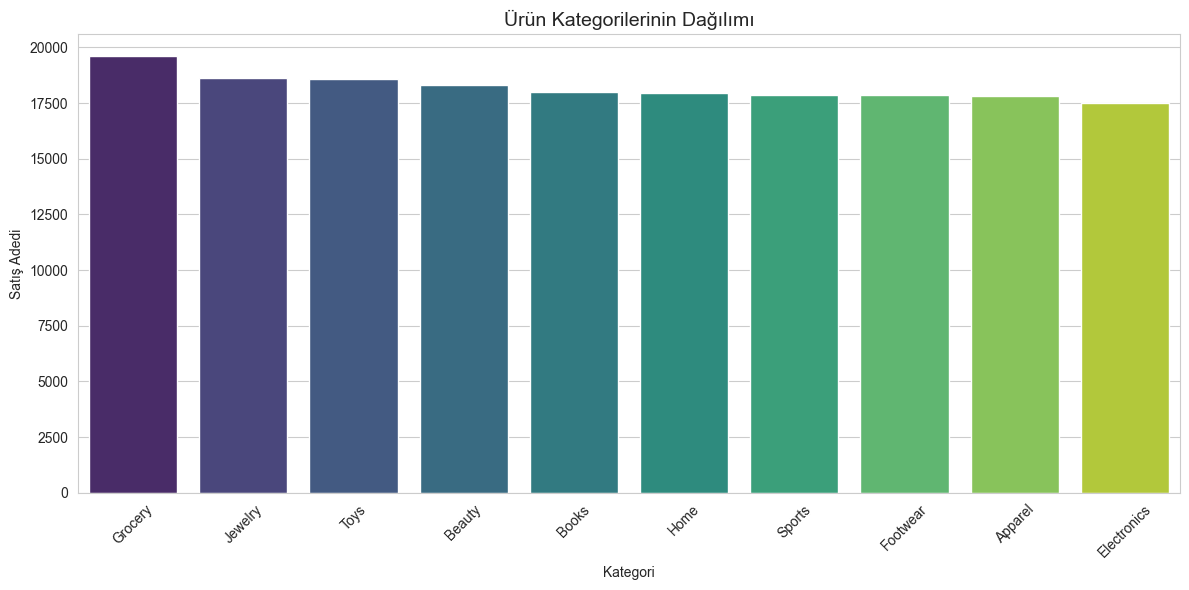

In [20]:
# Ürün kategorilerinin dağılımı
plt.figure(figsize=(12, 6))
kategori_sayilari = df['Category'].value_counts()
sns.barplot(x=kategori_sayilari.index, y=kategori_sayilari.values, palette='viridis')
plt.title('Ürün Kategorilerinin Dağılımı', fontsize=14)
plt.xlabel('Kategori')
plt.ylabel('Satış Adedi')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

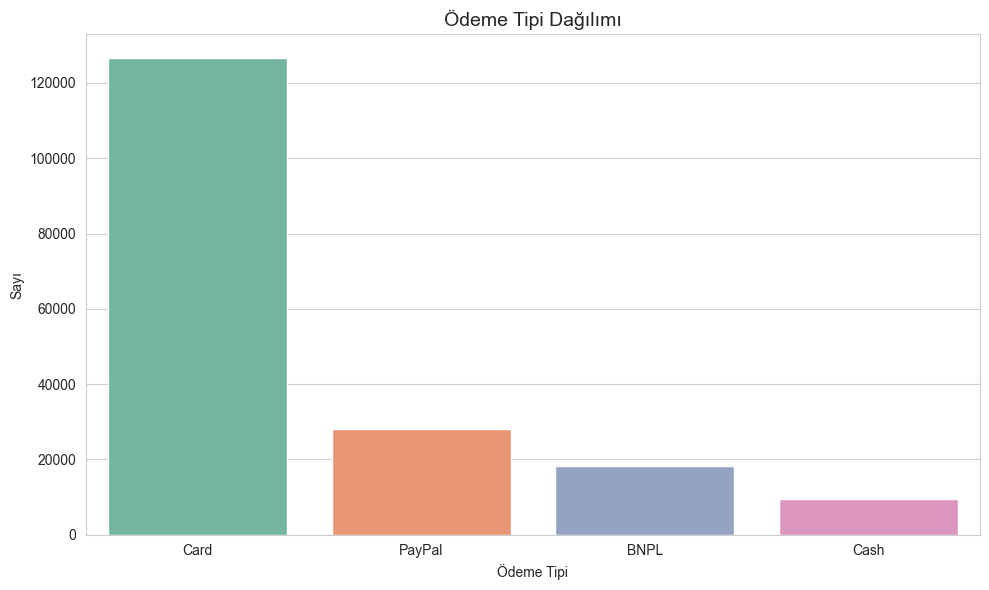

In [21]:
# Ödeme tipi dağılımı - countplot kullanımı
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='PaymentType', palette='Set2')
plt.title('Ödeme Tipi Dağılımı', fontsize=14)
plt.xlabel('Ödeme Tipi')
plt.ylabel('Sayı')
plt.tight_layout()
plt.show()

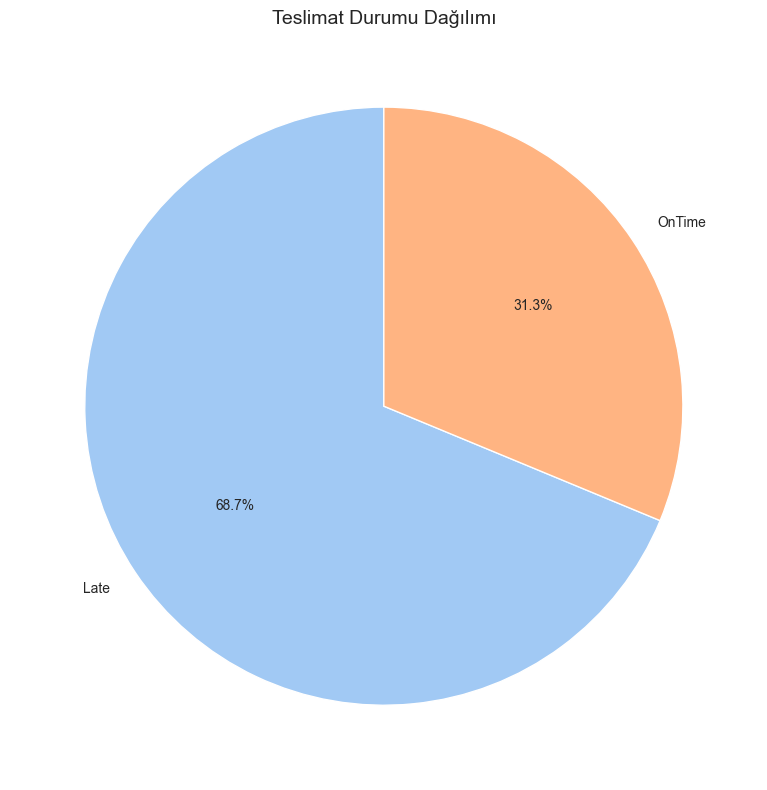

In [22]:
# Teslimat durumu dağılımı - pie chart
plt.figure(figsize=(10, 8))
teslimat_durumu = df['DeliveryStatus'].value_counts()
plt.pie(teslimat_durumu.values, labels=teslimat_durumu.index, autopct='%1.1f%%', 
        colors=sns.color_palette('pastel'), startangle=90)
plt.title('Teslimat Durumu Dağılımı', fontsize=14)
plt.tight_layout()
plt.show()

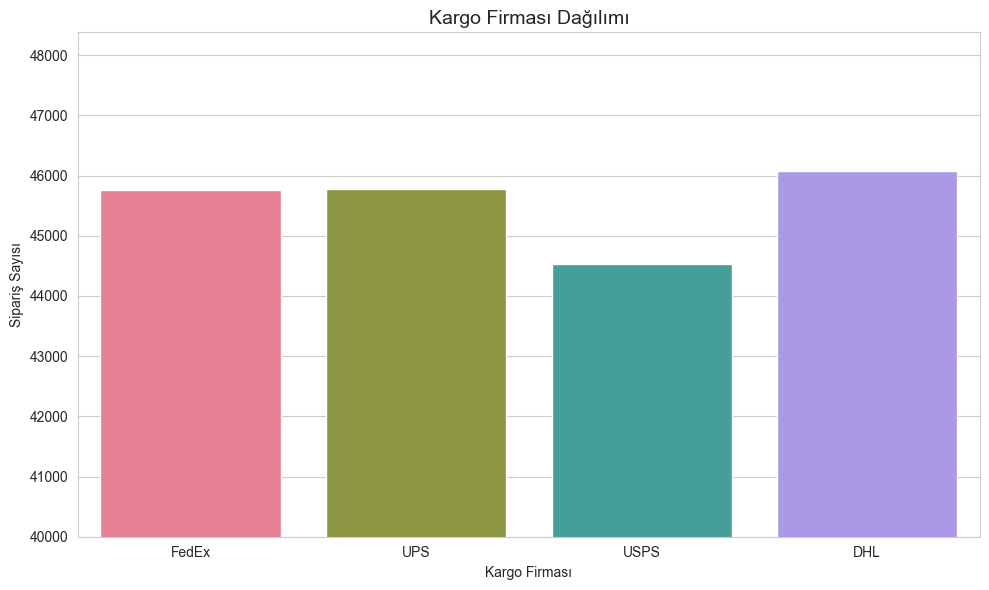

In [23]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Carrier', palette='husl')

plt.title('Kargo Firması Dağılımı', fontsize=14)
plt.xlabel('Kargo Firması')
plt.ylabel('Sipariş Sayısı')

plt.ylim(40000, None)  # Y ekseni 40.000’den başlar

plt.tight_layout()
plt.show()


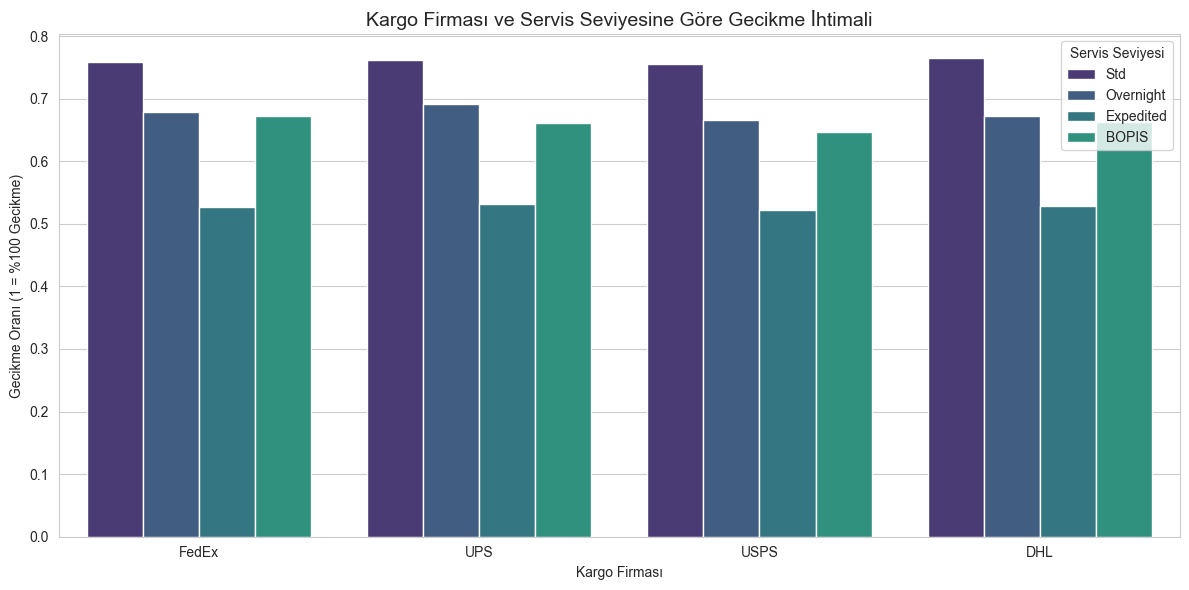

In [24]:
# Create Is_Late column if it doesn't exist
if 'Is_Late' not in df.columns:
	df['Is_Late'] = (df['Delay_Days'] > 0).astype(int)

# Kargo Firmasına Göre Gecikme Oranları (Bar Plot)
plt.figure(figsize=(12, 6))
# Sadece gecikenleri değil, genel ortalamayı görmek için:
sns.barplot(data=df, x='Carrier', y='Is_Late', hue='ServiceLevel', errorbar=None)
plt.title('Kargo Firması ve Servis Seviyesine Göre Gecikme İhtimali', fontsize=14)
plt.ylabel('Gecikme Oranı (1 = %100 Gecikme)')
plt.xlabel('Kargo Firması')
plt.legend(title='Servis Seviyesi')
plt.tight_layout()
plt.show()

### 4.2 Sayısal Olanlar

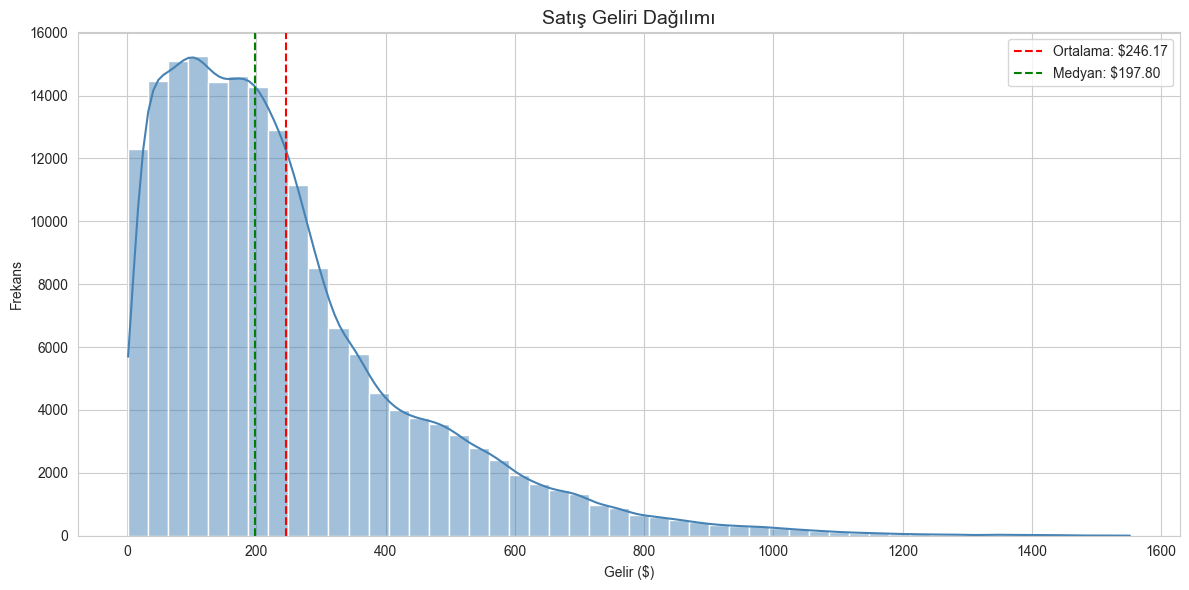

In [25]:
# Satis geliri dağılımı - histogram
plt.figure(figsize=(12, 6))
sns.histplot(df['LineRevenue$'], kde=True, bins=50, color='steelblue') # Histogram ve KDE çizimi
plt.title('Satış Geliri Dağılımı', fontsize=14)
plt.xlabel('Gelir ($)')
plt.ylabel('Frekans')

# Ortalama ve medyan çizgileri
plt.axvline(df['LineRevenue$'].mean(), color='red', linestyle='--', label=f'Ortalama: ${df["LineRevenue$"].mean():,.2f}') # Ortalama çizgisi
plt.axvline(df['LineRevenue$'].median(), color='green', linestyle='--', label=f'Medyan: ${df["LineRevenue$"].median():,.2f}') # Medyan çizgisi
plt.legend() # Legend gösterimi
plt.tight_layout() # Layout ayarları
plt.show()

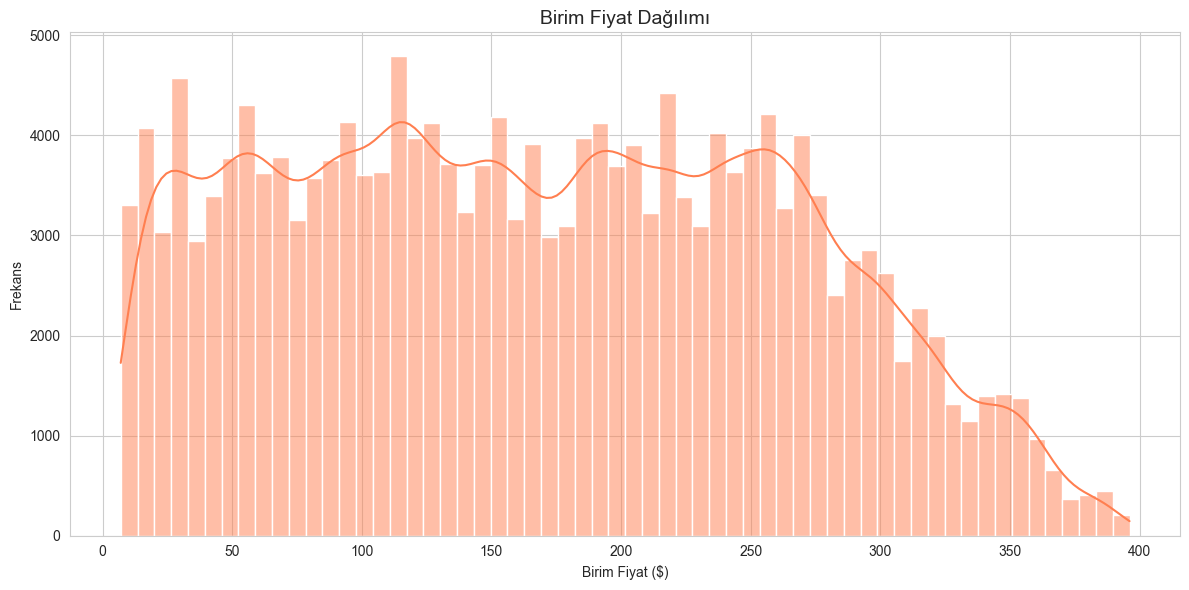

In [26]:
# Birim fiyat dağılımı - histogram
plt.figure(figsize=(12, 6))
sns.histplot(df['UnitPrice'], kde=True, bins=60, color='coral') # Histogram ve KDE çizimi
plt.title('Birim Fiyat Dağılımı', fontsize=14)
plt.xlabel('Birim Fiyat ($)')
plt.ylabel('Frekans')
plt.tight_layout()
plt.show()

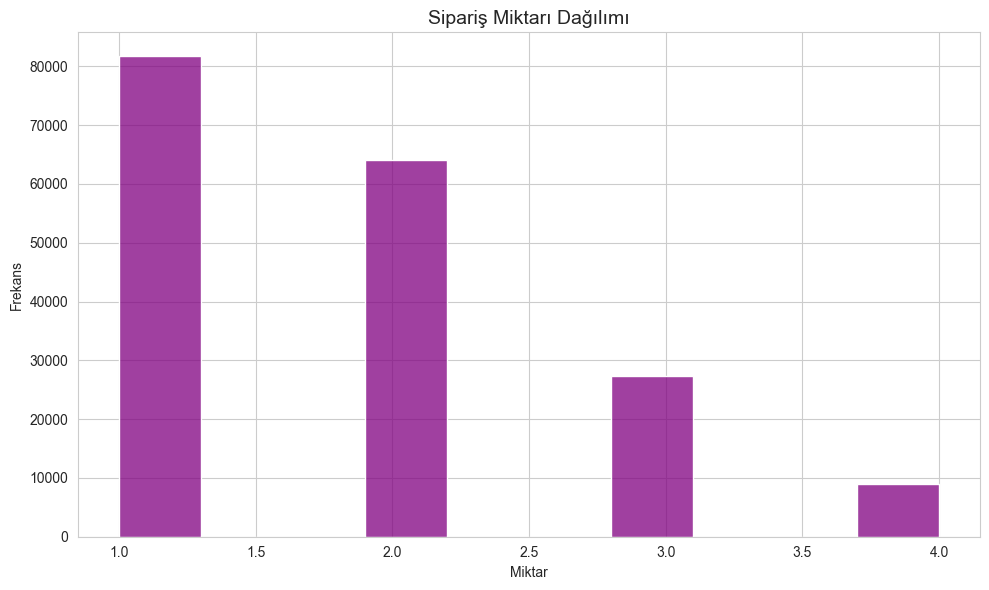

In [27]:
# Miktar dağılımı
plt.figure(figsize=(10, 6))
sns.histplot(df['Qty'], kde=False, bins=10, color='purple')
plt.title('Sipariş Miktarı Dağılımı', fontsize=14)
plt.xlabel('Miktar')
plt.ylabel('Frekans')
plt.tight_layout()
plt.show()

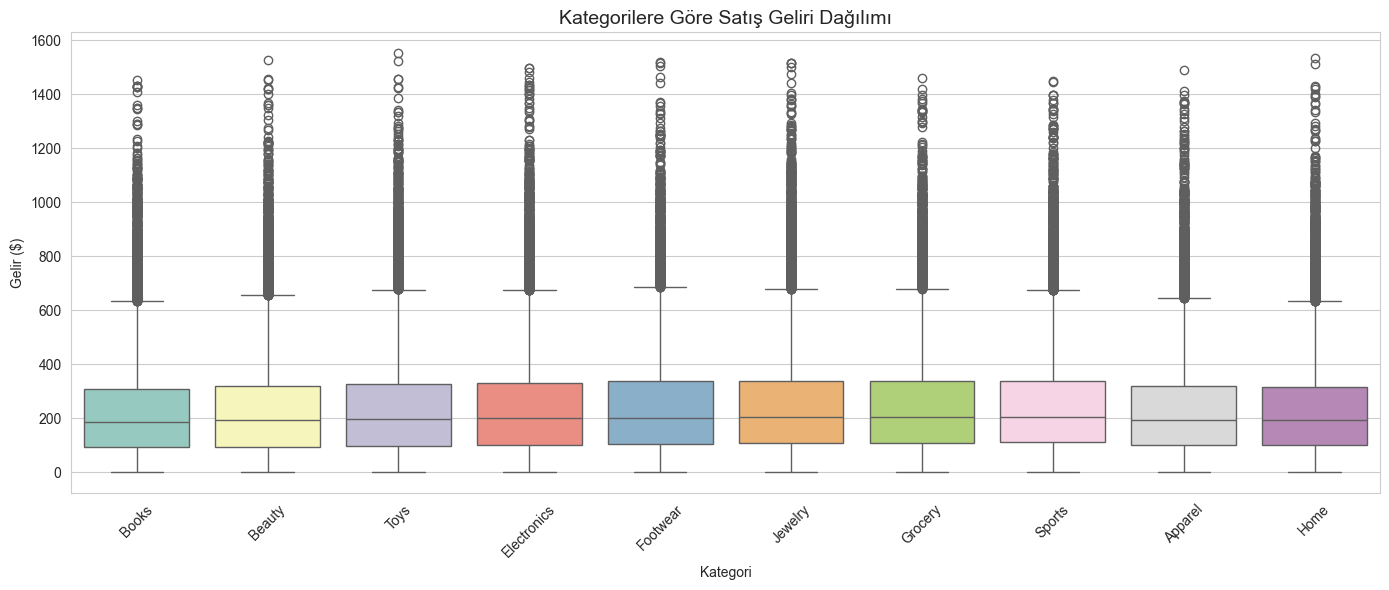

In [28]:
# Kategorilere göre gelir boxplot
plt.figure(figsize=(14, 6))
sns.boxplot(data=df, x='Category', y='LineRevenue$', palette='Set3')
plt.title('Kategorilere Göre Satış Geliri Dağılımı', fontsize=14)
plt.xlabel('Kategori')
plt.ylabel('Gelir ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

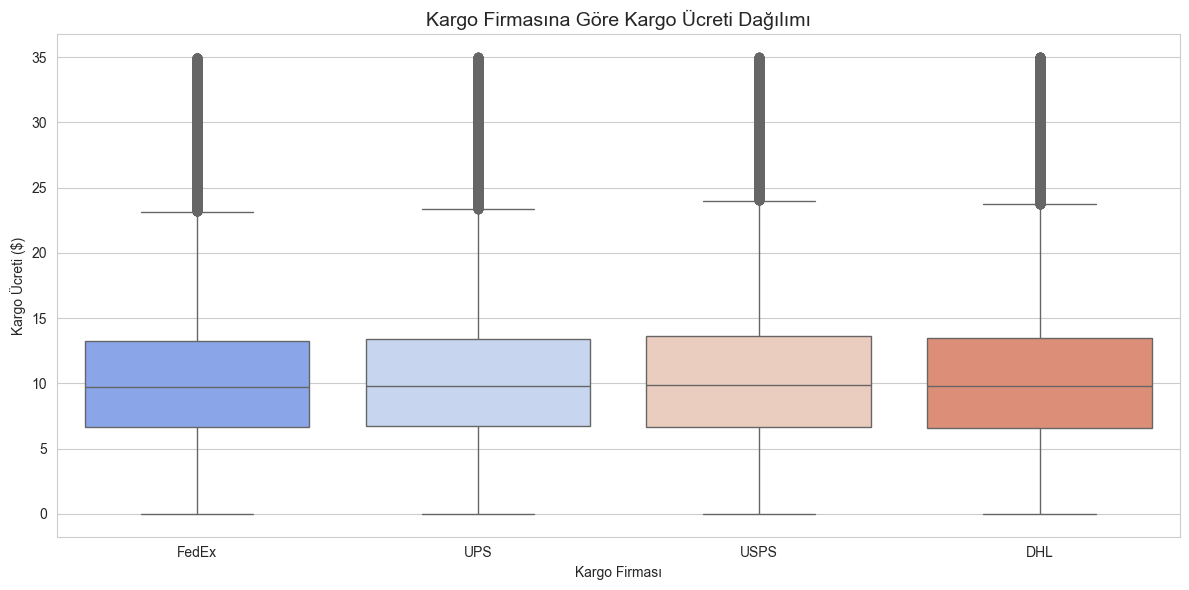

In [29]:
# Kargo firmasina göre kargo ücreti boxplot
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Carrier', y='ShipCost$', palette='coolwarm')
plt.title('Kargo Firmasına Göre Kargo Ücreti Dağılımı', fontsize=14)
plt.xlabel('Kargo Firması')
plt.ylabel('Kargo Ücreti ($)')
plt.tight_layout()
plt.show()

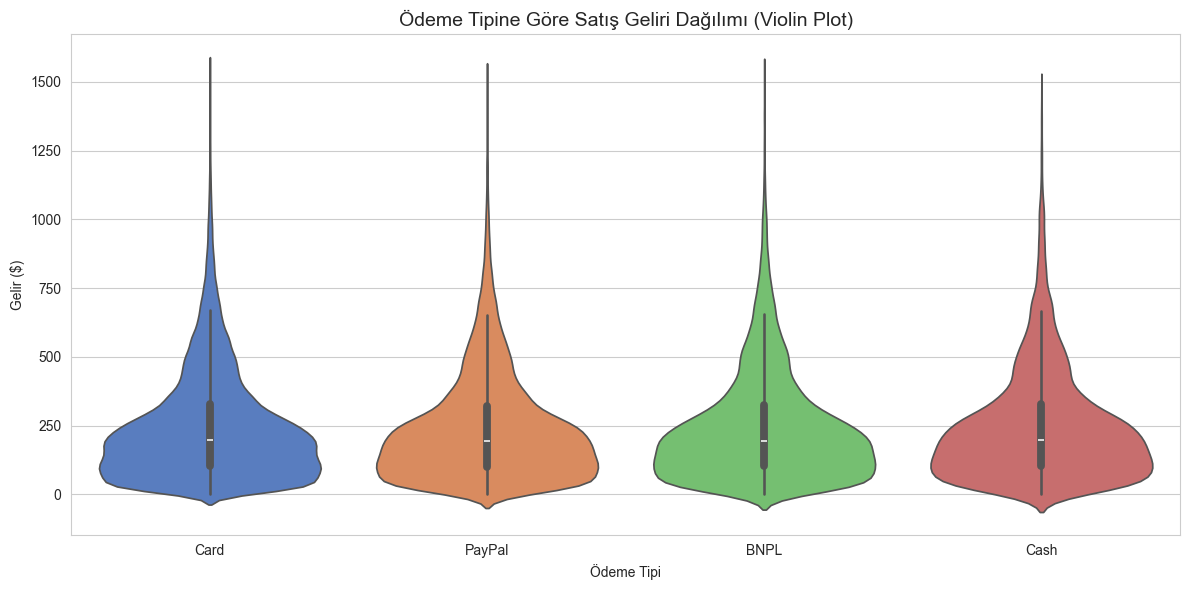

In [30]:
# Ödeme tipine göre gelir violin plot
plt.figure(figsize=(12, 6))
sns.violinplot(data=df, x='PaymentType', y='LineRevenue$', palette='muted')
plt.title('Ödeme Tipine Göre Satış Geliri Dağılımı (Violin Plot)', fontsize=14)
plt.xlabel('Ödeme Tipi')
plt.ylabel('Gelir ($)')
plt.tight_layout()
plt.show()

### 4.3 Korelasyon Analizi ve Heatmap Grafikleri

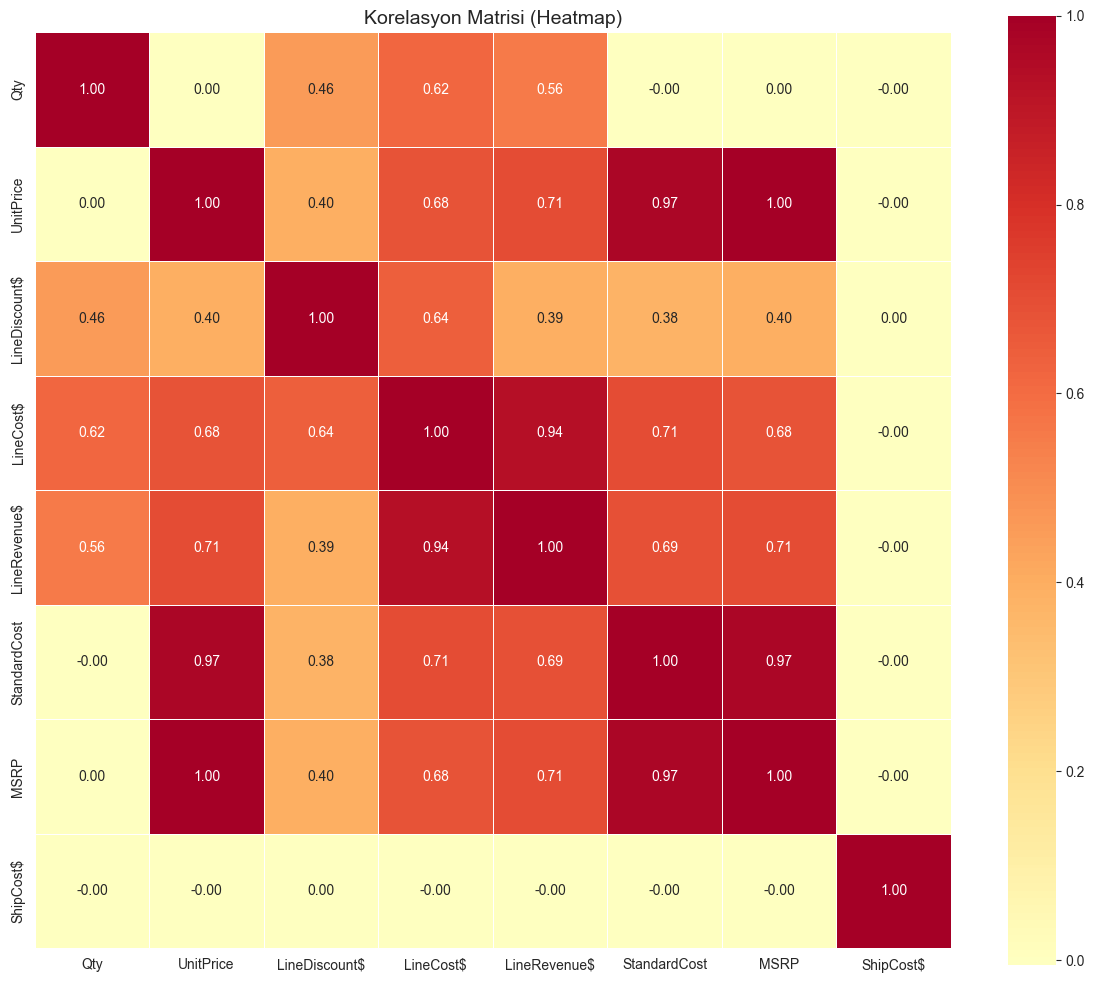

In [31]:
# Sayısal değişkenler arasındaki korelasyon
sayisal_sutunlar = ['Qty', 'UnitPrice', 'LineDiscount$', 'LineCost$', 'LineRevenue$', 
                    'StandardCost', 'MSRP', 'ShipCost$']

korelasyon = df[sayisal_sutunlar].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(korelasyon, annot=True, cmap='RdYlBu_r', center=0, fmt='.2f',
            square=True, linewidths=0.5)
plt.title('Korelasyon Matrisi (Heatmap)', fontsize=14)
plt.tight_layout()
plt.show()

1. Qty: Satın alınan ürün adedi
2. UnitPrice: Ürünün birim satış fiyatı
3. LineDiscount$: Sipariş satırına uygulanan toplam indirim tutarı
4. LineCost$: Sipariş satırındaki ürünlerin toplam maliyeti
5. LineRevenue$: Sipariş satırından elde edilen toplam gelir
6. StandardCost: Ürünün birim başına standart maliyeti
7. MSRP: Üretici tarafından önerilen perakende satış fiyatı
8. ShipCost$: Sipariş satırına ait kargo maliyeti


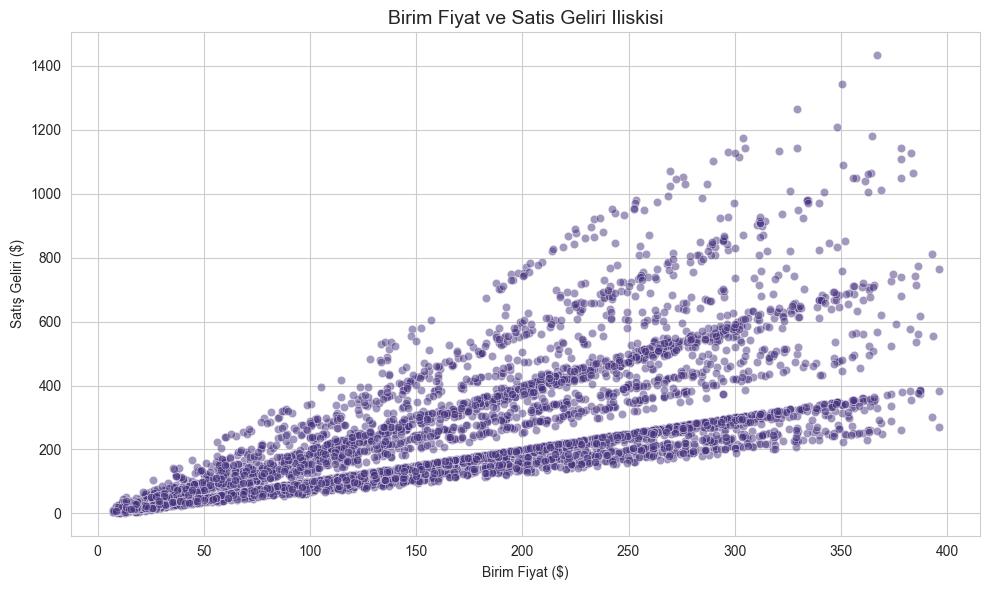

In [32]:
# Scatter plot - Birim fiyat ve Gelir ilişkisi
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df.sample(5000), x='UnitPrice', y='LineRevenue$', alpha=0.5)
plt.title('Birim Fiyat ve Satis Geliri Iliskisi', fontsize=14)
plt.xlabel('Birim Fiyat ($)')
plt.ylabel('Satış Geliri ($)')
plt.tight_layout()
plt.show()

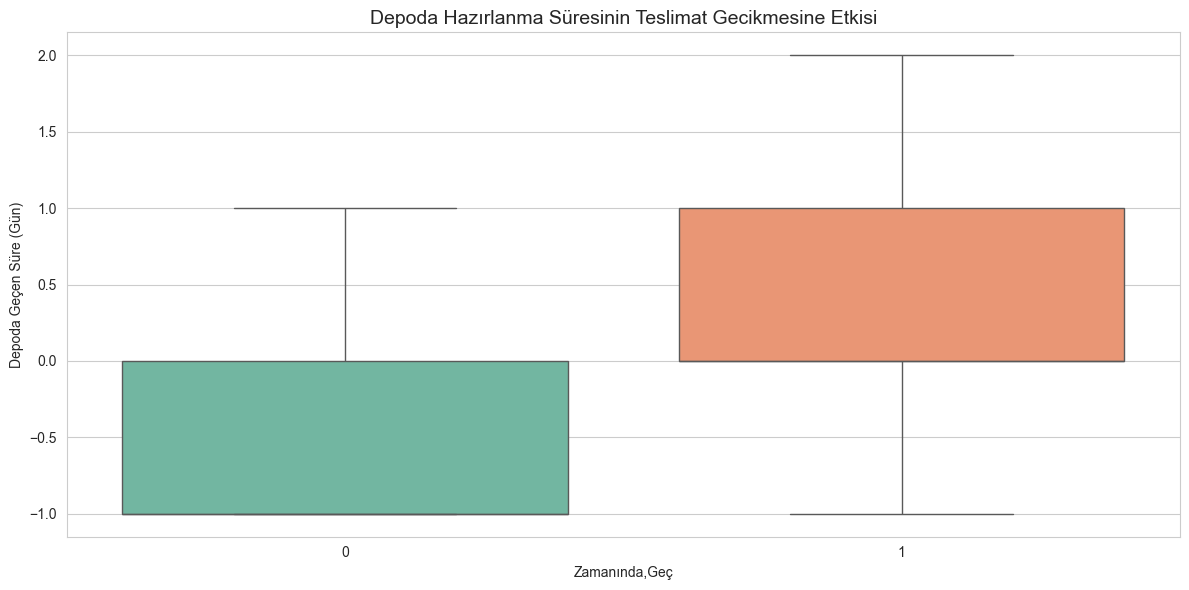

In [33]:

plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Is_Late', y='Warehouse_Process_Days', palette='Set2')
plt.title('Depoda Hazırlanma Süresinin Teslimat Gecikmesine Etkisi', fontsize=14)
plt.xlabel('Zamanında,Geç')
plt.ylabel('Depoda Geçen Süre (Gün)')
plt.tight_layout()
plt.show()

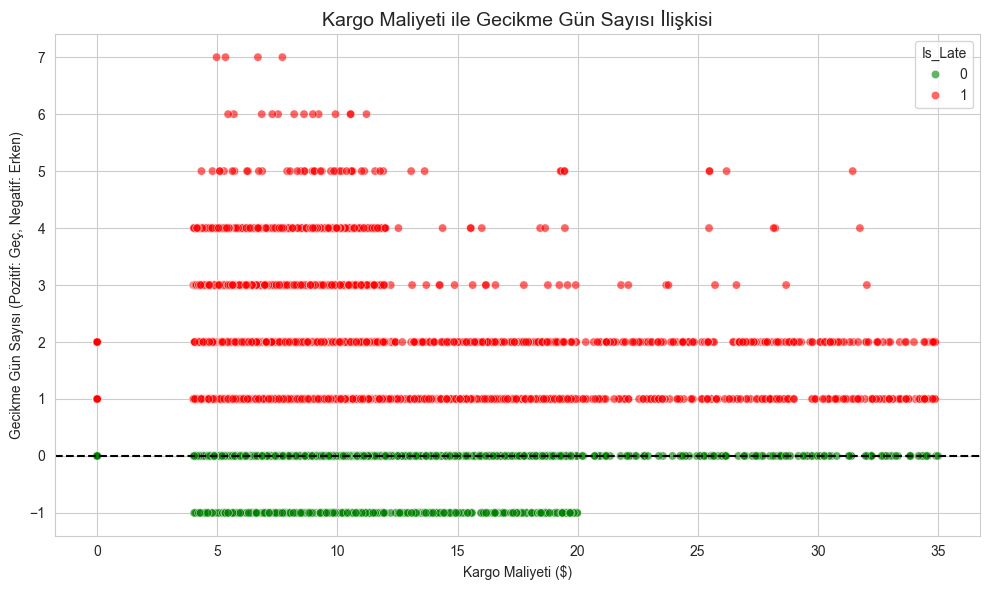

In [34]:
plt.figure(figsize=(10, 6))
# Çok fazla veri varsa sample olacak
sns.scatterplot(data=df.sample(min(5000, len(df))), 
                x='ShipCost$', 
                y='Delay_Days', 
                hue='Is_Late', 
                alpha=0.6, 
                palette={True: 'red', False: 'green'})
                
plt.axhline(0, color='black', linestyle='--') # 0 noktası (Zamanında teslim sınırı)
plt.title('Kargo Maliyeti ile Gecikme Gün Sayısı İlişkisi', fontsize=14)
plt.xlabel('Kargo Maliyeti ($)')
plt.ylabel('Gecikme Gün Sayısı (Pozitif: Geç, Negatif: Erken)')
plt.tight_layout()
plt.show()

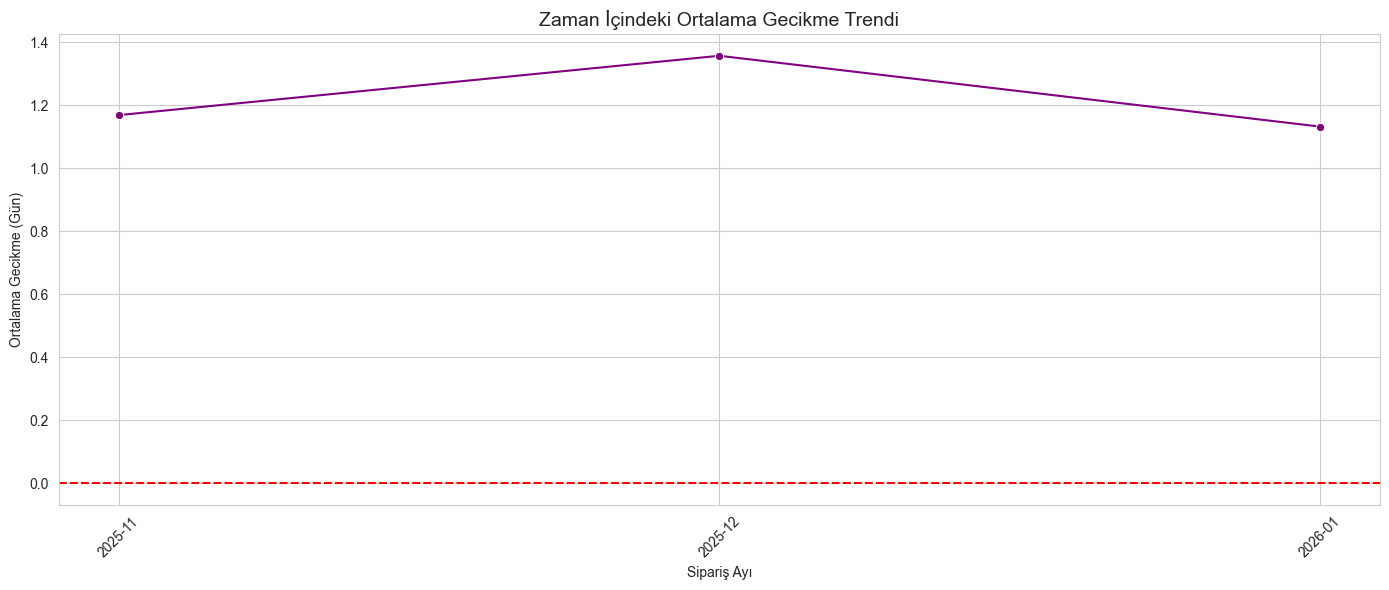

In [35]:
# Sipariş tarihini aylık bazda gruplayıp ortalama gecikme günü
df['Order_Month'] = df['OrderDateTime'].dt.to_period('M').astype(str)
monthly_delay = df.groupby('Order_Month')['Delay_Days'].mean().reset_index()

plt.figure(figsize=(14, 6))
sns.lineplot(data=monthly_delay, x='Order_Month', y='Delay_Days', marker='o', color='purple')
plt.axhline(0, color='red', linestyle='--', label='Zamanında Sınırı')
plt.xticks(rotation=45)
plt.title('Zaman İçindeki Ortalama Gecikme Trendi', fontsize=14)
plt.ylabel('Ortalama Gecikme (Gün)')
plt.xlabel('Sipariş Ayı')
plt.tight_layout()
plt.show()

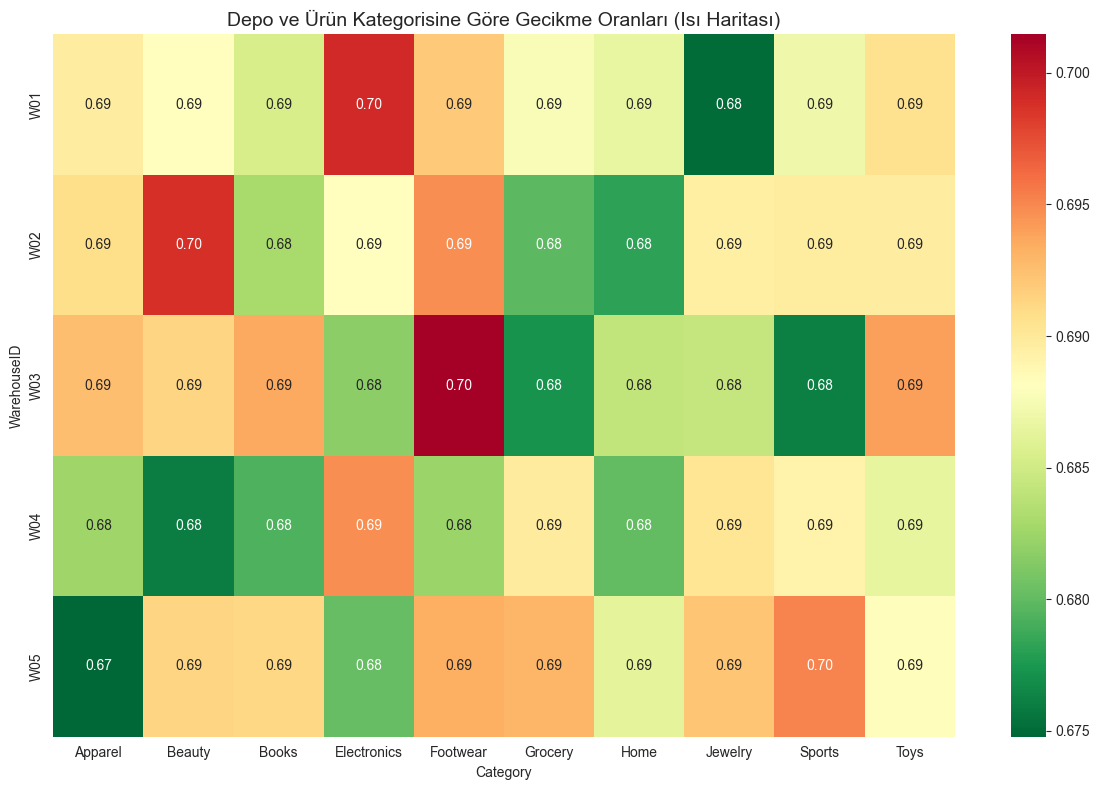

In [36]:
# Gecikme oranını (Is_Late ortalaması) pivot tablo yapalım
heatmap_data = df.pivot_table(index='WarehouseID', columns='Category', values='Is_Late', aggfunc='mean')

plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="RdYlGn_r") # Kırmızı yüksek gecikme demek
plt.title('Depo ve Ürün Kategorisine Göre Gecikme Oranları (Isı Haritası)', fontsize=14)
plt.tight_layout()
plt.show()

### 4.4 Gruplandırma ve Aggregation İşlemleri

In [37]:
# Kategorilere göre toplam gelir - groupby ve agg kullanimi
kategori_gelir = df.groupby('Category')['LineRevenue$'].agg(['sum', 'mean', 'count']).reset_index() #agg ile birden fazla istatistiksel özetleme yapıyoruz
kategori_gelir.columns = ['Kategori', 'Toplam Gelir', 'Ortalama Gelir', 'Satış Adedi']
kategori_gelir = kategori_gelir.sort_values('Toplam Gelir', ascending=False) #ascending burada küçükten büyüğe sıralama yapar

print("KATEGORİLERE GÖRE GELİR ANALİZİ")
kategori_gelir

KATEGORİLERE GÖRE GELİR ANALİZİ


,Kategori,Toplam Gelir,Ortalama Gelir,Satış Adedi
5,Grocery,4898149.25,249.841839,19605
7,Jewelry,4754395.83,255.064154,18640
9,Toys,4554430.44,245.138621,18579
8,Sports,4523718.05,253.174281,17868
4,Footwear,4504075.00,252.244344,17856
1,Beauty,4380488.19,239.018289,18327
3,Electronics,4368566.38,249.603838,17502
0,Apparel,4327071.42,242.698492,17829
6,Home,4306133.89,240.083290,17936
2,Books,4220740.85,234.537722,17996


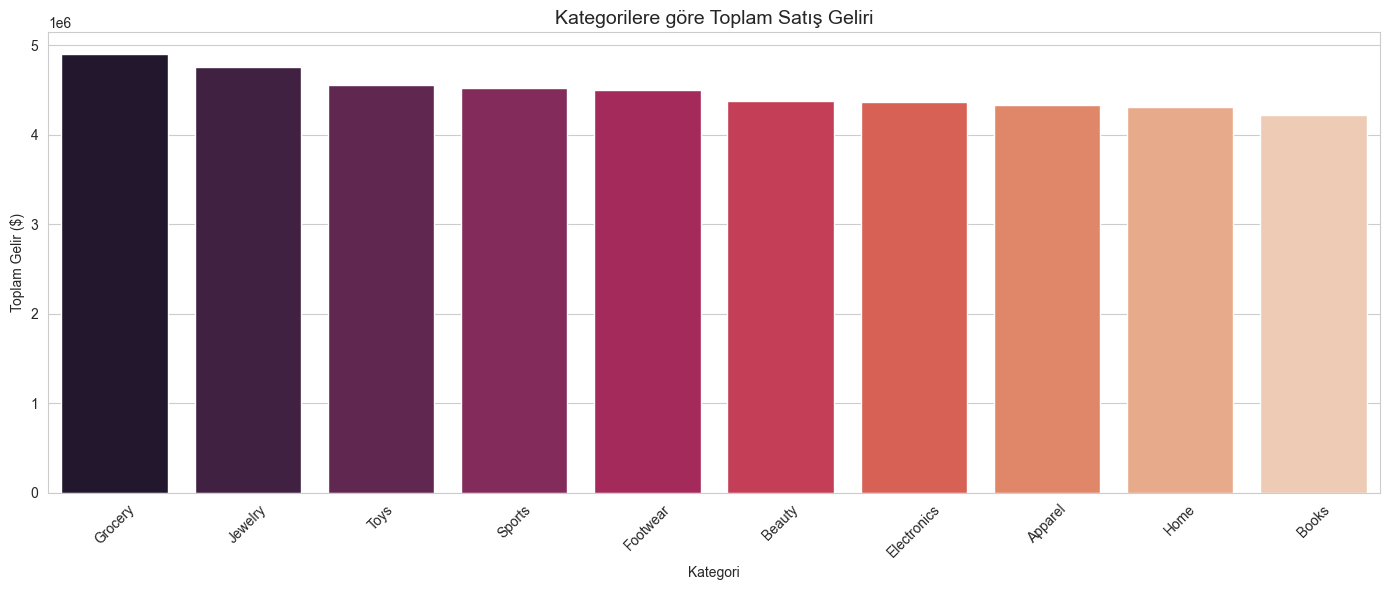

In [38]:
# Kategori bazlı toplam gelir grafiği
plt.figure(figsize=(14, 6))
sns.barplot(data=kategori_gelir, x='Kategori', y='Toplam Gelir', palette='rocket')
plt.title('Kategorilere göre Toplam Satış Geliri', fontsize=14)
plt.xlabel('Kategori')
plt.ylabel('Toplam Gelir ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [39]:
# Kargo firması ve teslimat durumu çapraz tablosu - pivot table
pivot_tablo = pd.pivot_table(df, values='OrderID',index='Carrier',columns='DeliveryStatus',aggfunc='count',fill_value=0) #fill_value ile eksik değerleri 0 ile dolduruyoruz

print("KARGO FİRMASI ve TESLİMAT DURUMU (PIVOT TABLE)")
pivot_tablo

KARGO FİRMASI ve TESLİMAT DURUMU (PIVOT TABLE)


DeliveryStatus,Late,OnTime
Carrier,,
DHL,31822,14254
FedEx,31458,14297
UPS,31665,14117
USPS,30274,14251


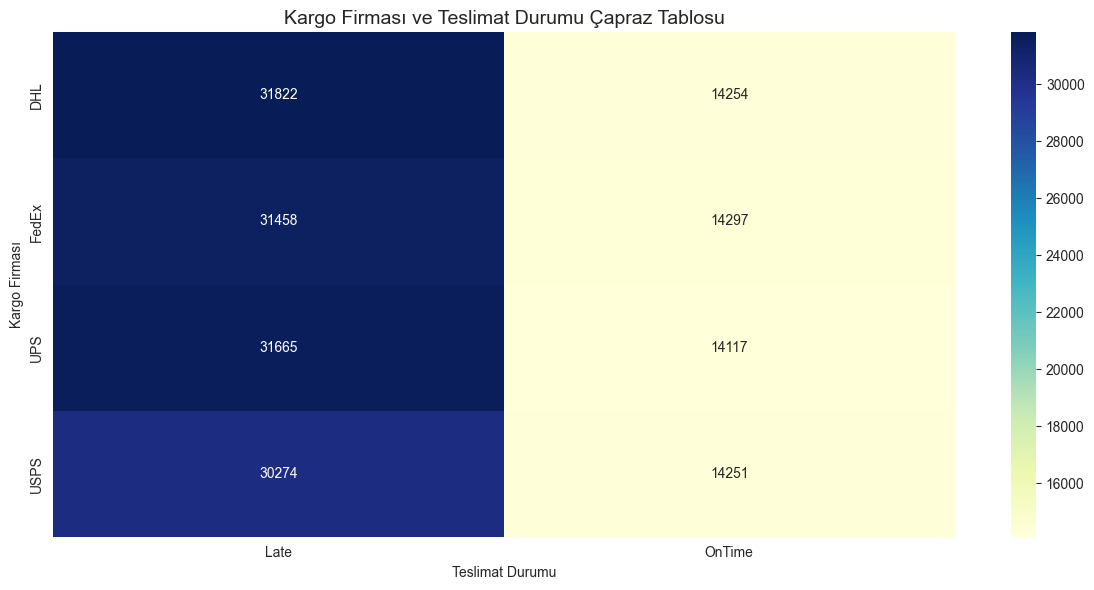

In [40]:
# Pivot table heatmap görselleştirmesi
plt.figure(figsize=(12, 6))
sns.heatmap(pivot_tablo, annot=True, fmt='d', cmap='YlGnBu') # fmt='d' ile tam sayı formatında gösterim
plt.title('Kargo Firması ve Teslimat Durumu Çapraz Tablosu', fontsize=14) # Başlık
plt.xlabel('Teslimat Durumu') # X Başlık
plt.ylabel('Kargo Firması') # Y Başlık
plt.tight_layout()
plt.show()

# 5. İstatistiksel Testler

Bu bölümde veri setindeki ilişkileri ve dağılımları istatistiksel olarak inceliyoruz.

**Not:** Bu testler Keşifçi Veri Analizi (EDA) kapsamındadır ve modelleme bölümünden ayrı tutulmuştur.
P-değeri < 0.05 ise sonuç istatistiksel olarak anlamlıdır.

In [41]:
from scipy.stats import shapiro

# Normallik testi - Shapiro-Wilk testi
# Büyük veri setlerinde örneklem alıyoruz
orneklem = df['LineRevenue$'].sample(1000, random_state=42)

stat, p_value = shapiro(orneklem)

print("SHAPIRO-WILK NORMALLIK TESTİ")
print(f"Test İstatistiği: {stat:.4f}")
print(f"P-değeri: {p_value:.4f}")
print()

alpha = 0.05
if p_value > alpha:
    print(f"P-değeri ({p_value:.4f}) > alpha ({alpha})")
    print("Sonuç:Normal bir Dağılım vardır.")
else:
    print(f"P-değeri ({p_value:.4f}) < alpha ({alpha})")
    print("Sonuç: Normal Dağılım Yok")

SHAPIRO-WILK NORMALLIK TESTİ
Test İstatistiği: 0.8929
P-değeri: 0.0000

P-değeri (0.0000) < alpha (0.05)
Sonuç: Normal Dağılım Yok


In [42]:
# Card ve PayPal ödeme tiplerine göre gelir karşılaştırması
card_gelir = df[df['PaymentType'] == 'Card']['LineRevenue$']
paypal_gelir = df[df['PaymentType'] == 'PayPal']['LineRevenue$']

stat, p_value = stats.ttest_ind(card_gelir.sample(1000, random_state=42),paypal_gelir.sample(1000, random_state=42))

print("BAGIMSIZ ORNEKLEM T-TESTI")
print("Card vs PayPal Gelir Karşılaştırması")
print(f"Card Ortalama Gelir: ${card_gelir.mean():,.2f}")
print(f"PayPal Ortalama Gelir: ${paypal_gelir.mean():,.2f}")
print(f"T-istatistiği: {stat:.4f}")
print(f"P-değeri: {p_value:.4f}")
print()

alpha = 0.05
if p_value > alpha:
    print(f"Sonuç: İki grup arasında istatistiksel olarak anlamlı fark yoktur (p > {alpha}).")
else:
    print(f"Sonuç: İki grup arasında istatistiksel olarak anlamlı fark vardır (p < {alpha}).")

BAGIMSIZ ORNEKLEM T-TESTI
Card vs PayPal Gelir Karşılaştırması
Card Ortalama Gelir: $246.97
PayPal Ortalama Gelir: $242.18
T-istatistiği: -1.4036
P-değeri: 0.1606

Sonuç: İki grup arasında istatistiksel olarak anlamlı fark yoktur (p > 0.05).


In [43]:
# Kargo firmalarına göre kargo ücreti karşılaştırması (ANOVA)
kargo_firmalari = df['Carrier'].unique()
gruplar = [df[df['Carrier'] == kargo]['ShipCost$'].dropna() for kargo in kargo_firmalari]

stat, p_value = stats.f_oneway(*gruplar)

print("TEK YÖNLÜ ANOVA TESTİ")
print("Kargo Firmalarına Göre Kargo Ücreti Karşılaştırması")
print("=" * 50)

for kargo in kargo_firmalari:
    ort = df[df['Carrier'] == kargo]['ShipCost$'].mean()
    print(f"{kargo} Ortalama Kargo Ücreti: ${ort:.2f}")

print(f"\nF-istatistiği: {stat:.4f}")
print(f"P-değeri: {p_value:.4f}")
print()

alpha = 0.05
if p_value > alpha:
    print(f"Sonuç: Gruplar arasında istatistiksel olarak anlamlı fark yoktur (p > {alpha}).")
else:
    print(f"Sonuç: En az iki grup arasında istatistiksel olarak anlamlı fark vardır (p < {alpha}).")

TEK YÖNLÜ ANOVA TESTİ
Kargo Firmalarına Göre Kargo Ücreti Karşılaştırması
FedEx Ortalama Kargo Ücreti: $11.06
UPS Ortalama Kargo Ücreti: $11.14
USPS Ortalama Kargo Ücreti: $11.15
DHL Ortalama Kargo Ücreti: $11.15

F-istatistiği: 1.7005
P-değeri: 0.1645

Sonuç: Gruplar arasında istatistiksel olarak anlamlı fark yoktur (p > 0.05).


In [44]:
# UnitPrice ve LineRevenue$ arasındaki korelasyon
korelasyon_katsayisi, p_value = stats.pearsonr(df['UnitPrice'], df['LineRevenue$'])

print("PEARSON KORELASYON TESTİ")
print("Birim Fiyat ve Satış Geliri İlişkisi")
print("=" * 50)
print(f"Korelasyon Katsayısı (r): {korelasyon_katsayisi:.4f}")
print(f"P-değeri: {p_value:.4e}")
print()

# Korelasyon yorumu
if abs(korelasyon_katsayisi) >= 0.7:
    guc = "güçlü"
elif abs(korelasyon_katsayisi) >= 0.4:
    guc = "orta düzeyde"
else:
    guc = "zayıf"

yon = "pozitif" if korelasyon_katsayisi > 0 else "negatif"

print(f"Yorum: İki değişken arasında {guc} {yon} ilişki vardır.")

PEARSON KORELASYON TESTİ
Birim Fiyat ve Satış Geliri İlişkisi
Korelasyon Katsayısı (r): 0.7090
P-değeri: 0.0000e+00

Yorum: İki değişken arasında güçlü pozitif ilişki vardır.


# 6. Veri Ön İşleme

### 6.1 Değişken oluşturma

In [45]:
# Teslimat durumu dagilimini inceleyelim
print("TESLİMAT DURUMU DAĞILIMI")
print(df['DeliveryStatus'].value_counts())
print()
print(df['DeliveryStatus'].value_counts(normalize=True).round(4) * 100)

TESLİMAT DURUMU DAĞILIMI
DeliveryStatus
Late      125219
OnTime     56919
Name: count, dtype: int64

DeliveryStatus
Late      68.75
OnTime    31.25
Name: proportion, dtype: float64


In [46]:
# Hedef değişkeni matematiksel olarak oluşturuyoruz
# Gecikme = DeliveryDate - PromisedDate
# Eğer gecikme > 0 ise 0 (Başarısız/Gecikmeli), değilse 1 (Başarılı/Zamanında)
# Bu yöntem, metin sütununa (DeliveryStatus) güvenmek yerine doğrudan tarih farkını kullanır

# Not: Delay_Days değişkeni daha önce (görselleştirme bölümünde) oluşturulmuştu
# df['Delay_Days'] = (df['DeliveryDate'] - df['PromisedDate']).dt.days

# Hedef değişken: Gecikme günü <= 0 ise başarılı (1), > 0 ise başarısız (0)
df['Basarili_Teslimat'] = (df['Delay_Days'] <= 0).astype(int)

print("HEDEF DEĞİŞKEN DAĞILIMI")
print("=" * 50)
print(df['Basarili_Teslimat'].value_counts())
print()
print(f"Başarılı Teslimat Oranı: %{df['Basarili_Teslimat'].mean() * 100:.2f}")
print(f"Başarısız (Gecikmeli) Teslimat Oranı: %{(1 - df['Basarili_Teslimat'].mean()) * 100:.2f}")
print("\nNot: Hedef değişken, teslimat tarihi ile vaat edilen tarih arasındaki farka göre hesaplanmıştır.")

HEDEF DEĞİŞKEN DAĞILIMI
Basarili_Teslimat
0    125219
1     56919
Name: count, dtype: int64

Başarılı Teslimat Oranı: %31.25
Başarısız (Gecikmeli) Teslimat Oranı: %68.75

Not: Hedef değişken, teslimat tarihi ile vaat edilen tarih arasındaki farka göre hesaplanmıştır.


### 6.2 Özellik Seçimi ve Veriyi Model İçin Hazırlama

In [47]:
# Model için kullanılacak özellikleri seçiyoruz
# Kritik: Teslimat durumunu tahmin etmek için tarih farkları en önemli veridir
# Bu nedenle Delay_Days ve Warehouse_Process_Days değişkenlerini modele dahil ediyoruz

# Önce Warehouse_Process_Days hesaplayalım (Depo İşleme Süresi)
# ShipDate - OrderDateTime = Siparişten kargoya verilene kadar geçen süre
df['Warehouse_Process_Days'] = (df['ShipDate'] - df['OrderDateTime']).dt.days

# Kategorik değişkenler: Category, PaymentType, Carrier, ServiceLevel
# Sayısal değişkenler: Qty, UnitPrice, LineRevenue$, ShipCost$, Warehouse_Process_Days
# NOT: Delay_Days ve DeliveryDate MODELE DAHİL EDİLMEMELİ (Data Leakage önlemi)
# Çünkü bu değişkenler geleceği gösterir - gerçek hayatta teslimat öncesi bilinmezler

model_df = df[['Category', 'PaymentType', 'Carrier', 'ServiceLevel',
               'Qty', 'UnitPrice', 'LineRevenue$', 'ShipCost$', 
               'Warehouse_Process_Days', 'Basarili_Teslimat']].copy()

# Eksik verileri kontrol edelim
print("EKSİK VERİ KONTROLÜ")
print(model_df.isnull().sum())

# Warehouse_Process_Days'deki eksik değerleri medyan ile dolduralım
if model_df['Warehouse_Process_Days'].isnull().sum() > 0:
    model_df['Warehouse_Process_Days'].fillna(model_df['Warehouse_Process_Days'].median(), inplace=True)
    print("\nWarehouse_Process_Days eksik değerleri medyan ile dolduruldu.")

EKSİK VERİ KONTROLÜ
Category                  0
PaymentType               0
Carrier                   0
ServiceLevel              0
Qty                       0
UnitPrice                 0
LineRevenue$              0
ShipCost$                 0
Warehouse_Process_Days    0
Basarili_Teslimat         0
dtype: int64


In [48]:
print(f"Son veri seti boyutu: {model_df.shape}")


Son veri seti boyutu: (182138, 10)


### 6.3 Label Encoding (Kategorik olanların sayısala dönüştüğü yer)

In [49]:
# Label Encoder nesnesi olusturuyoruz
le = LabelEncoder()

# Kategorik sütünlari donusturuyoruz
kategorik_sutunlar = ['Category', 'PaymentType', 'Carrier', 'ServiceLevel']

for sutun in kategorik_sutunlar:
    model_df[sutun + '_encoded'] = le.fit_transform(model_df[sutun])
    print(f"{sutun} donusturuldu.")
    print(f"Benzersiz değerler: {model_df[sutun].nunique()}")
    print()

Category donusturuldu.
Benzersiz değerler: 10

PaymentType donusturuldu.
Benzersiz değerler: 4

Carrier donusturuldu.
Benzersiz değerler: 4

ServiceLevel donusturuldu.
Benzersiz değerler: 4



In [50]:
# Dönüştürülmüş veri bu şekilde
model_df.head()

,Category,PaymentType,Carrier,ServiceLevel,Qty,UnitPrice,LineRevenue$,ShipCost$,Warehouse_Process_Days,Basarili_Teslimat,Category_encoded,PaymentType_encoded,Carrier_encoded,ServiceLevel_encoded
0,Books,Card,FedEx,Std,2,323.19,601.16,5.08,0,0,2,1,1,3
1,Beauty,Card,FedEx,Std,3,34.66,96.71,5.08,0,0,1,1,1,3
2,Toys,Card,FedEx,Std,1,76.08,70.76,5.08,0,0,9,1,1,3
3,Electronics,Card,FedEx,Std,3,45.45,126.81,5.08,0,0,3,1,1,3
4,Footwear,Card,FedEx,Std,1,78.55,73.05,5.08,0,0,4,1,1,3


### 6.4 Özellik ve Hedef Değişkenlerinin Ayrılması


In [51]:
# Bağımsız değişkenler (X) ve bağımlı değişken (y)
# Warehouse_Process_Days özelliğini de ekliyoruz - teslimat tahmininde önemli bir faktör
ozellik_sutunlari = ['Qty', 'UnitPrice', 'LineRevenue$', 'ShipCost$',
                     'Category_encoded', 'PaymentType_encoded', 
                     'Carrier_encoded', 'ServiceLevel_encoded',
                     'Warehouse_Process_Days']

X = model_df[ozellik_sutunlari]
y = model_df['Basarili_Teslimat']

print("ÖZELLİK MATRİSİ (X)")
print(f"Boyut: {X.shape}")
print(f"Özellikler: {X.columns.tolist()}")
print()
print("HEDEF DEĞİŞKEN (y)")
print(f"Boyut: {y.shape}")

ÖZELLİK MATRİSİ (X)
Boyut: (182138, 9)
Özellikler: ['Qty', 'UnitPrice', 'LineRevenue$', 'ShipCost$', 'Category_encoded', 'PaymentType_encoded', 'Carrier_encoded', 'ServiceLevel_encoded', 'Warehouse_Process_Days']

HEDEF DEĞİŞKEN (y)
Boyut: (182138,)


### 6.5 Eğitim ve Test Seti Oluşturma

In [52]:
# Veriyi %80 eğitim, %20 test olarak ayırıyoruz
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print("VERİ SETİ BÖLÜNMESİ")
print(f"Eğitim seti boyutu: {X_train.shape[0]} satır")
print(f"Test seti boyutu: {X_test.shape[0]} satır")
print(f"\nEğitim seti oranı: %{len(X_train) / len(X) * 100:.0f}")
print(f"Test seti oranı: %{len(X_test) / len(X) * 100:.0f}")

VERİ SETİ BÖLÜNMESİ
Eğitim seti boyutu: 145710 satır
Test seti boyutu: 36428 satır

Eğitim seti oranı: %80
Test seti oranı: %20


### 6.6 Ölçeklendirme

In [53]:
# StandardScaler ile ölçeklendirme
scaler = StandardScaler()

# Eğitim seti üzerinde fit ve transform
X_train_scaled = scaler.fit_transform(X_train)

# Test seti üzerinde sadece transform (fit yok - veri sızıntısını önlemek için)
X_test_scaled = scaler.transform(X_test)

print("ÖLÇEKLENDİRME TAMAMLANDI")
print(f"Ölçeklendirme öncesi - Eğitim seti ortalaması: {X_train.mean().mean():.4f}")
print(f"Ölçeklendirme sonrası - Eğitim seti ortalaması: {X_train_scaled.mean():.4f}")

ÖLÇEKLENDİRME TAMAMLANDI
Ölçeklendirme öncesi - Eğitim seti ortalaması: 48.6053
Ölçeklendirme sonrası - Eğitim seti ortalaması: 0.0000


# 7. Makine Öğrenmesi

#### 7.1 Lojistik Regresyon

In [54]:
# class_weight='balanced' ekliyoruz
# Bu, az olan sınıfa (Başarılı) daha fazla matematiksel ağırlık verir.
log_reg = LogisticRegression(solver='liblinear', random_state=42, class_weight='balanced')

log_reg.fit(X_train_scaled, y_train)

# Tahmin
y_pred_log = log_reg.predict(X_test_scaled)

print("LOJISTIK REGRESYON SONUCLARI (DENGELENMİŞ)")
# Buradaki eğitim doğruluğu biraz düşebilir ama True Positive (Başarılı) yakalamaya başlar.
print(f"Egitim Dogrulugu: %{log_reg.score(X_train_scaled, y_train) * 100:.2f}")
print(f"Test Dogrulugu: %{accuracy_score(y_test, y_pred_log) * 100:.2f}")

LOJISTIK REGRESYON SONUCLARI (DENGELENMİŞ)
Egitim Dogrulugu: %78.55
Test Dogrulugu: %78.25


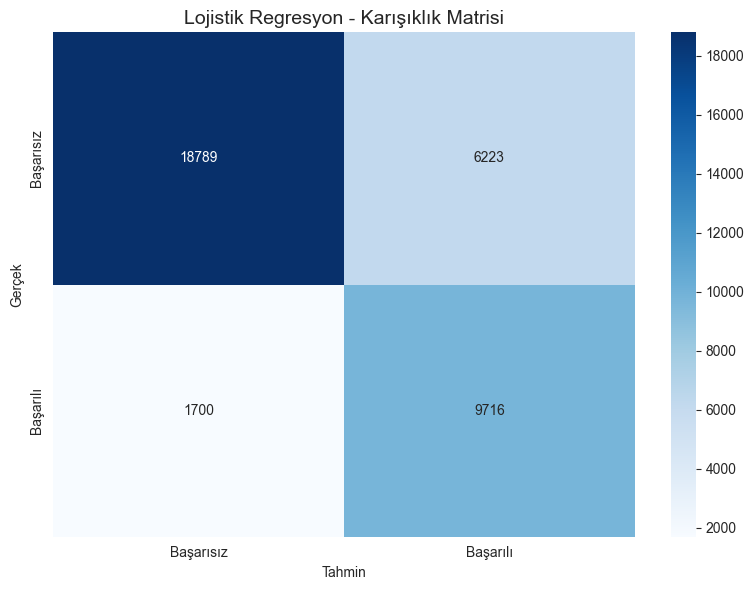

In [55]:

# Karışıklık Matrisi (Confusion Matrix)
cm_log = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Başarısız', 'Başarılı'],
            yticklabels=['Başarısız', 'Başarılı'])
plt.title('Lojistik Regresyon - Karışıklık Matrisi', fontsize=14)
plt.xlabel('Tahmin')
plt.ylabel('Gerçek')
plt.tight_layout()
plt.show()

In [56]:
# Sınıflandırma Raporu
print("SINIFLANDIRMA RAPORU - LOJİSTİK REGRESYON")
print("=" * 50)
print(classification_report(y_test, y_pred_log, target_names=['Başarısız', 'Başarılı']))
print()
print("YORUM:")
print("Lojistik Regresyon modeli dengesiz veri setinde makul bir performans göstermiştir.")
print("F1-Score değerleri incelendiğinde, 'Başarısız' sınıfı daha iyi tahmin edilmektedir.")
print("Bu durum, veri setindeki sınıf dengesizliğinden kaynaklanmaktadır.")

SINIFLANDIRMA RAPORU - LOJİSTİK REGRESYON
              precision    recall  f1-score   support

   Başarısız       0.92      0.75      0.83     25012
    Başarılı       0.61      0.85      0.71     11416

    accuracy                           0.78     36428
   macro avg       0.76      0.80      0.77     36428
weighted avg       0.82      0.78      0.79     36428


YORUM:
Lojistik Regresyon modeli dengesiz veri setinde makul bir performans göstermiştir.
F1-Score değerleri incelendiğinde, 'Başarısız' sınıfı daha iyi tahmin edilmektedir.
Bu durum, veri setindeki sınıf dengesizliğinden kaynaklanmaktadır.


### 7.2 Karar Ağacı

In [57]:

# Karar Ağacı modeli
# class_weight='balanced' ekle
dt_model = DecisionTreeClassifier(random_state=42, max_depth=10, class_weight='balanced')
dt_model.fit(X_train_scaled, y_train)

# Tahmin
y_pred_dt = dt_model.predict(X_test_scaled)

print("KARAR AĞACI SONUÇLARI")
print("=" * 50)
print(f"Eğitim Doğruluğu: %{dt_model.score(X_train_scaled, y_train) * 100:.2f}")
print(f"Test Doğruluğu: %{accuracy_score(y_test, y_pred_dt) * 100:.2f}")

KARAR AĞACI SONUÇLARI
Eğitim Doğruluğu: %80.43
Test Doğruluğu: %79.97


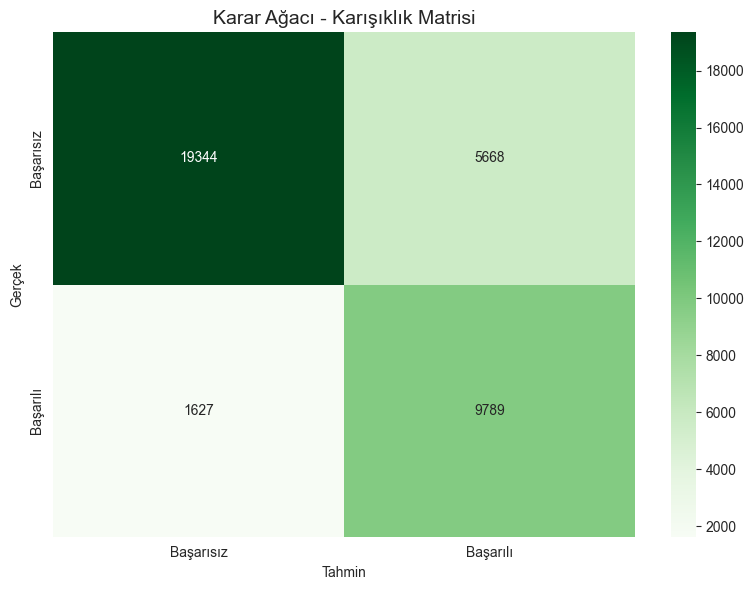


SINIFLANDIRMA RAPORU - KARAR AĞACI
              precision    recall  f1-score   support

   Başarısız       0.92      0.77      0.84     25012
    Başarılı       0.63      0.86      0.73     11416

    accuracy                           0.80     36428
   macro avg       0.78      0.82      0.78     36428
weighted avg       0.83      0.80      0.81     36428


YORUM:
Karar Ağacı modeli, özellikle ServiceLevel ve ShipCost değişkenlerine
yüksek önem atayarak teslimat başarısını tahmin etmektedir.


In [58]:
# Karar Ağacı - Karışıklık Matrisi
cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Başarısız', 'Başarılı'],
            yticklabels=['Başarısız', 'Başarılı'])
plt.title('Karar Ağacı - Karışıklık Matrisi', fontsize=14)
plt.xlabel('Tahmin')
plt.ylabel('Gerçek')
plt.tight_layout()
plt.show()

# Sınıflandırma Raporu
print("\nSINIFLANDIRMA RAPORU - KARAR AĞACI")
print("=" * 50)
print(classification_report(y_test, y_pred_dt, target_names=['Başarısız', 'Başarılı']))
print()
print("YORUM:")
print("Karar Ağacı modeli, özellikle ServiceLevel ve ShipCost değişkenlerine")
print("yüksek önem atayarak teslimat başarısını tahmin etmektedir.")

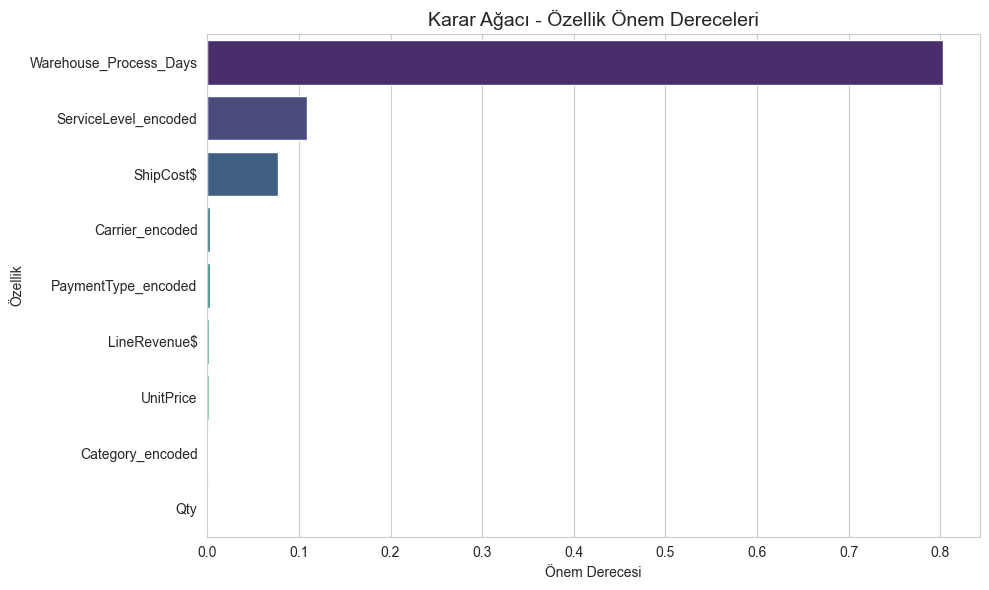

In [59]:
# Özellik Önem Dereceleri
ozellik_onemleri = pd.DataFrame({
    'Özellik': ozellik_sutunlari,
    'Önem': dt_model.feature_importances_
}).sort_values('Önem', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=ozellik_onemleri, x='Önem', y='Özellik', palette='viridis')
plt.title('Karar Ağacı - Özellik Önem Dereceleri', fontsize=14)
plt.xlabel('Önem Derecesi')
plt.ylabel('Özellik')
plt.tight_layout()
plt.show()

1. ServiceLevel_encoded: Hizmet Seviyesi (Kodlanmış)

2. ShipCost$: Kargo Maliyeti ($)

3. LineRevenue$: Satır Geliri / Toplam Kalem Tutarı ($)

4. PaymentType_encoded: Ödeme Türü (Kodlanmış)

5. Carrier_encoded: Taşıyıcı / Kargo Firması (Kodlanmış)

6. UnitPrice: Birim Fiyat

7. Category_encoded: Kategori (Kodlanmış)

8. Qty (Quantity): Miktar / Adet

### 7.3 Random Forest

In [60]:
# Random Forest modeli
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    max_depth=15,  
    class_weight='balanced'
)
rf_model.fit(X_train_scaled, y_train)

# Tahmin
y_pred_rf = rf_model.predict(X_test_scaled)

print("RANDOM FOREST SONUCLARI")
print(f"Eğitim Doğruluğu: %{rf_model.score(X_train_scaled, y_train) * 100:.2f}")
print(f"Test Doğruluğu: %{accuracy_score(y_test, y_pred_rf) * 100:.2f}")

RANDOM FOREST SONUCLARI
Eğitim Doğruluğu: %81.69
Test Doğruluğu: %80.06


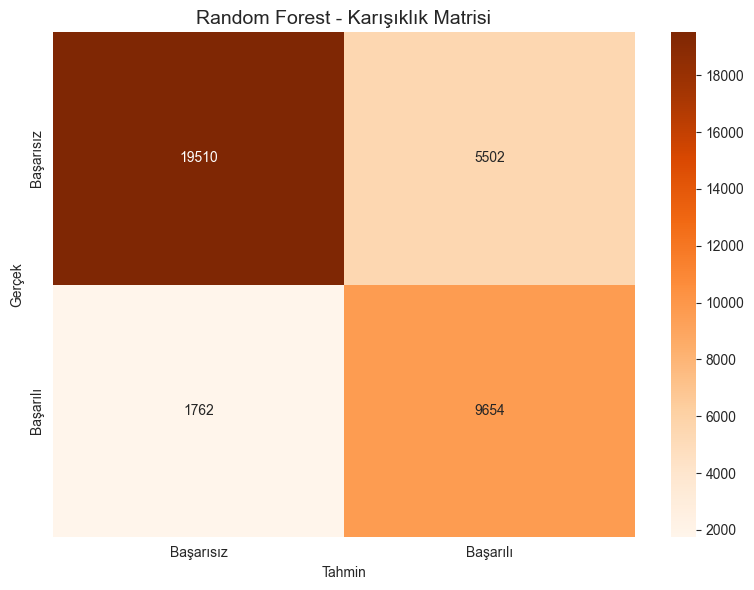


SINIFLANDIRMA RAPORU - RANDOM FOREST
              precision    recall  f1-score   support

   Başarısız       0.92      0.78      0.84     25012
    Başarılı       0.64      0.85      0.73     11416

    accuracy                           0.80     36428
   macro avg       0.78      0.81      0.78     36428
weighted avg       0.83      0.80      0.81     36428


YORUM:
Random Forest modeli en iyi performansı göstermiştir. Bunun nedeni:
1. Birden fazla karar ağacının kombinasyonu ile daha güçlü tahminler
2. Kategorik ve sürekli değişkenleri birlikte iyi yönetmesi
3. Overfitting'e karşı daha dayanıklı olması


In [61]:
# Random Forest - Karışıklık Matrisi
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Başarısız', 'Başarılı'],
            yticklabels=['Başarısız', 'Başarılı'])
plt.title('Random Forest - Karışıklık Matrisi', fontsize=14)
plt.xlabel('Tahmin')
plt.ylabel('Gerçek')
plt.tight_layout()
plt.show()

# Sınıflandırma Raporu
print("\nSINIFLANDIRMA RAPORU - RANDOM FOREST")
print("=" * 50)
print(classification_report(y_test, y_pred_rf, target_names=['Başarısız', 'Başarılı']))
print()
print("YORUM:")
print("Random Forest modeli en iyi performansı göstermiştir. Bunun nedeni:")
print("1. Birden fazla karar ağacının kombinasyonu ile daha güçlü tahminler")
print("2. Kategorik ve sürekli değişkenleri birlikte iyi yönetmesi")
print("3. Overfitting'e karşı daha dayanıklı olması")

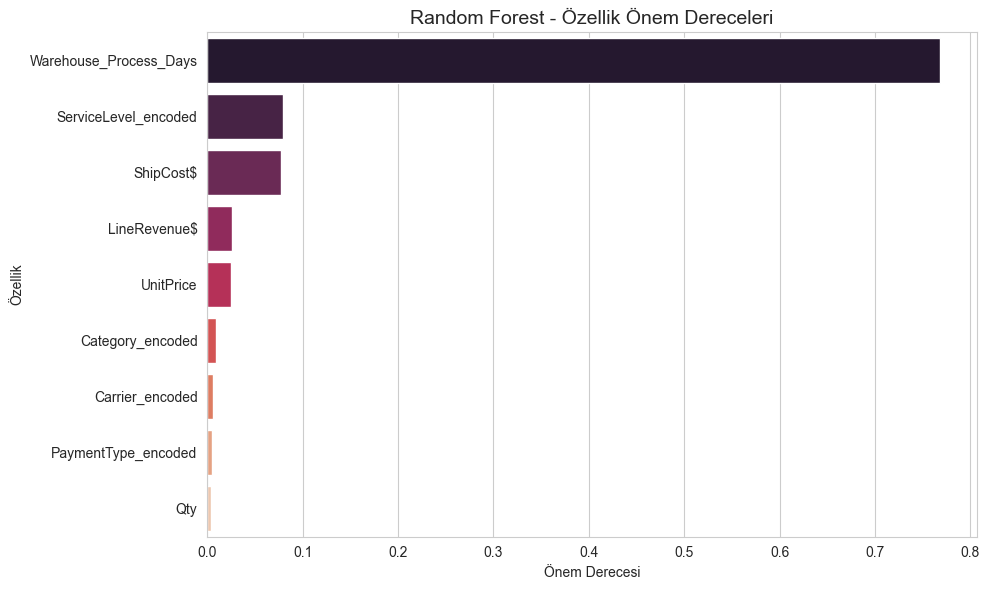

In [62]:
# Random Forest - Özellik Önem Dereceleri
rf_ozellik_onemleri = pd.DataFrame({
    'Özellik': ozellik_sutunlari,
    'Önem': rf_model.feature_importances_
}).sort_values('Önem', ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(data=rf_ozellik_onemleri, x='Önem', y='Özellik', palette='rocket')
plt.title('Random Forest - Özellik Önem Dereceleri', fontsize=14)
plt.xlabel('Önem Derecesi')
plt.ylabel('Özellik')
plt.tight_layout()
plt.show()

1. ShipCost$: Kargo Maliyeti ($)

2. ServiceLevel_encoded: Hizmet Seviyesi (Kodlanmış)

3. LineRevenue$: Satır Geliri / Toplam Kalem Tutarı ($)

4. UnitPrice: Birim Fiyat

5. Category_encoded: Kategori (Kodlanmış)

6. Carrier_encoded: Taşıyıcı / Kargo Firması (Kodlanmış)

7. PaymentType_encoded: Ödeme Türü (Kodlanmış)

8. Qty: Miktar / Adet

### 7.4 KNN (En Yakın Komşu)

In [63]:
# metric='manhattan' genelde yüksek boyutlu verilerde euclidean'dan daha iyi çalışabilir, denenebilir.
knn_model = KNeighborsClassifier(n_neighbors=5, weights='distance', metric='minkowski')

knn_model.fit(X_train_scaled, y_train)

# Tahmin
y_pred_knn = knn_model.predict(X_test_scaled)

print("K-EN YAKIN KOMŞU (KNN) SONUÇLARI (AĞIRLIKLI)")
print(f"Eğitim Doğruluğu: %{knn_model.score(X_train_scaled, y_train) * 100:.2f}")
print(f"Test Doğruluğu: %{accuracy_score(y_test, y_pred_knn) * 100:.2f}")

K-EN YAKIN KOMŞU (KNN) SONUÇLARI (AĞIRLIKLI)
Eğitim Doğruluğu: %100.00
Test Doğruluğu: %79.22


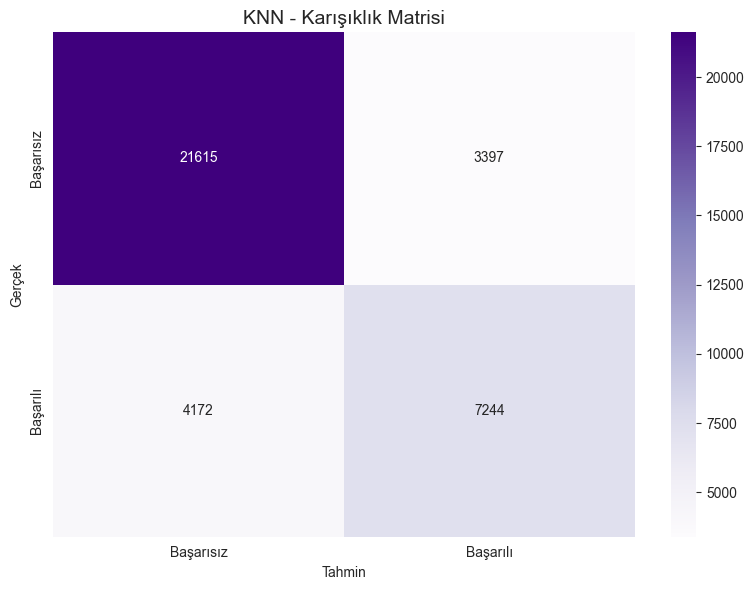


SINIFLANDIRMA RAPORU - KNN
              precision    recall  f1-score   support

   Başarısız       0.84      0.86      0.85     25012
    Başarılı       0.68      0.63      0.66     11416

    accuracy                           0.79     36428
   macro avg       0.76      0.75      0.75     36428
weighted avg       0.79      0.79      0.79     36428




In [64]:
# KNN - Karışıklık Matrisi
cm_knn = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Başarısız', 'Başarılı'],
            yticklabels=['Başarısız', 'Başarılı'])
plt.title('KNN - Karışıklık Matrisi', fontsize=14)
plt.xlabel('Tahmin')
plt.ylabel('Gerçek')
plt.tight_layout()
plt.show()

# Sınıflandırma Raporu
print("\nSINIFLANDIRMA RAPORU - KNN")
print(classification_report(y_test, y_pred_knn, target_names=['Başarısız', 'Başarılı']))
print()

In [65]:
# Tüm modellerin sonuçlarını karşılaştıralım
model_sonuclari = pd.DataFrame({
    'Model': ['Lojistik Regresyon', 'Karar Ağacı', 'Random Forest', 'KNN'],
    'Eğitim Doğruluğu': [
        log_reg.score(X_train_scaled, y_train) * 100,
        dt_model.score(X_train_scaled, y_train) * 100,
        rf_model.score(X_train_scaled, y_train) * 100,
        knn_model.score(X_train_scaled, y_train) * 100
    ],
    'Test Doğruluğu': [
        accuracy_score(y_test, y_pred_log) * 100,
        accuracy_score(y_test, y_pred_dt) * 100,
        accuracy_score(y_test, y_pred_rf) * 100,
        accuracy_score(y_test, y_pred_knn) * 100
    ]
}).round(2)

print("MODEL KARŞILAŞTIRMA TABLOSU")
print(model_sonuclari.to_string(index=False))
print()
print("Not: Test doğruluğu, modelin görülmemiş veriler üzerindeki performansını gösterir.")
print("Eğitim ve test doğruluğu arasındaki büyük fark, overfitting işareti olabilir.")

MODEL KARŞILAŞTIRMA TABLOSU
             Model  Eğitim Doğruluğu  Test Doğruluğu
Lojistik Regresyon             78.55           78.25
       Karar Ağacı             80.43           79.97
     Random Forest             81.69           80.06
               KNN            100.00           79.22

Not: Test doğruluğu, modelin görülmemiş veriler üzerindeki performansını gösterir.
Eğitim ve test doğruluğu arasındaki büyük fark, overfitting işareti olabilir.


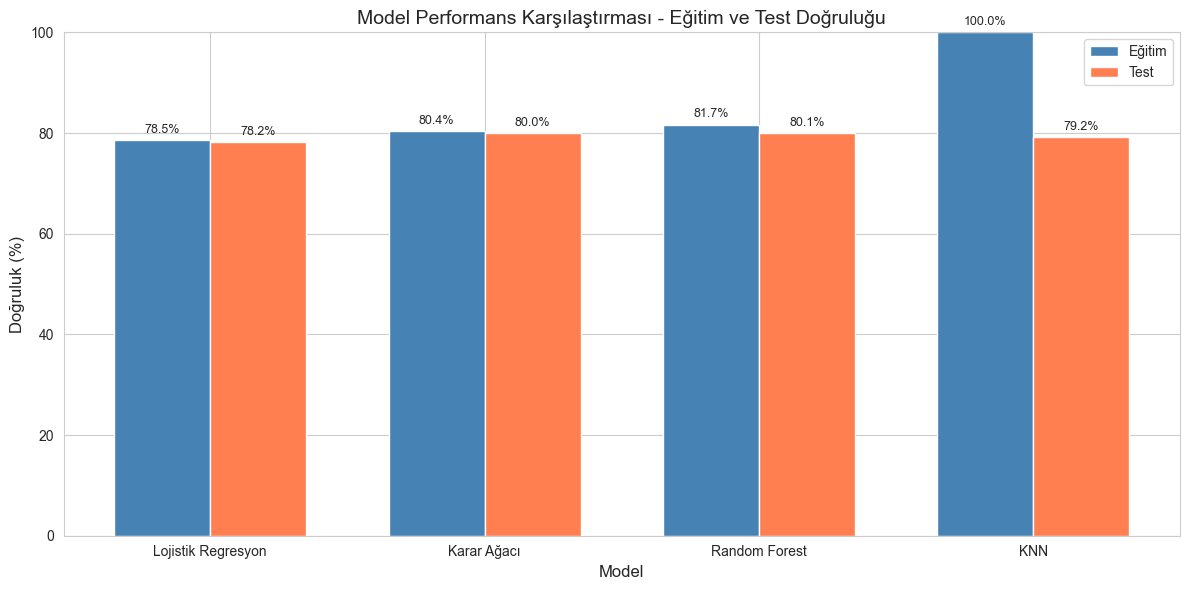

In [66]:
# Model karşılaştırma grafiği
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(model_sonuclari))
width = 0.35

bars1 = ax.bar(x - width/2, model_sonuclari['Eğitim Doğruluğu'], width, label='Eğitim', color='steelblue')
bars2 = ax.bar(x + width/2, model_sonuclari['Test Doğruluğu'], width, label='Test', color='coral')

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Doğruluk (%)', fontsize=12)
ax.set_title('Model Performans Karşılaştırması - Eğitim ve Test Doğruluğu', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(model_sonuclari['Model'])
ax.legend()
ax.set_ylim(0, 100)

# Değerleri barların üzerine yazalım
for bar in bars1:
    height = bar.get_height()
    ax.annotate(f'{height:.1f}%', xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9)

for bar in bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.1f}%', xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

### 7.5 ROC Eğrisi ve AUC

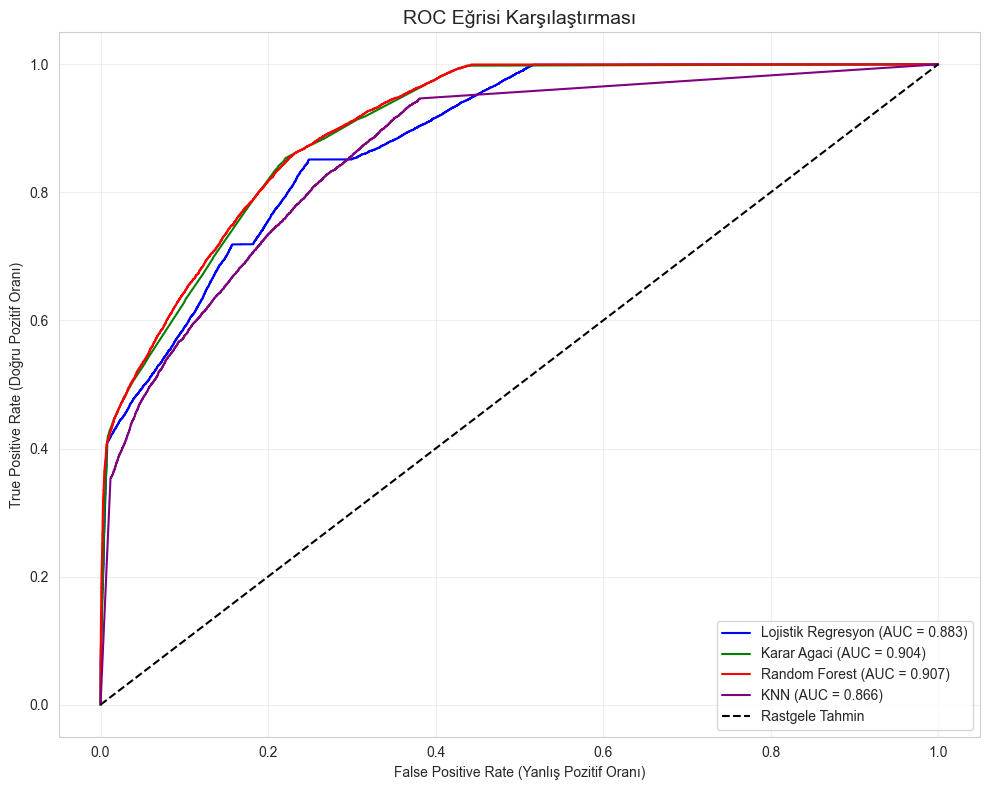

In [67]:
from sklearn.metrics import roc_auc_score

# ROC eğrisini cizelim
plt.figure(figsize=(10, 8))

# Her model için ROC eğrisi
modeller = {
    'Lojistik Regresyon': (log_reg, 'blue'),
    'Karar Agaci': (dt_model, 'green'),
    'Random Forest': (rf_model, 'red'),
    'KNN': (knn_model, 'purple')
}

for model_adi, (model, renk) in modeller.items():
    # Olasilik tahminleri
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    # ROC egrisi değerleri
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    
    plt.plot(fpr, tpr, color=renk, label=f'{model_adi} (AUC = {auc:.3f})')

# Referans cizgisi (rastgele tahmin)
plt.plot([0, 1], [0, 1], 'k--', label='Rastgele Tahmin')

plt.xlabel('False Positive Rate (Yanlış Pozitif Oranı)')
plt.ylabel('True Positive Rate (Doğru Pozitif Oranı)')
plt.title('ROC Eğrisi Karşılaştırması', fontsize=14)
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 7.6 Çarpraz Doğrulama

In [68]:
# ==============================================================================
# 5-KATLI ÇAPRAZ DOĞRULAMA (Cross-Validation)
# ==============================================================================
# Çapraz doğrulama, modelin farklı veri alt kümelerinde tutarlı performans
# gösterip göstermediğini test eder. Bu, modelin genelleme yeteneğini ölçer.

print("5-KATLI ÇAPRAZ DOĞRULAMA SONUÇLARI")


modeller = {
    'Lojistik Regresyon': LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced'),
    'Karar Ağacı': DecisionTreeClassifier(random_state=42, max_depth=10, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, max_depth=15, class_weight='balanced'),
    'KNN': KNeighborsClassifier(n_neighbors=5, metric='manhattan')
}

cv_sonuclari = {}

for model_adi, model in modeller.items():
    cv_skorlari = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy')
    cv_sonuclari[model_adi] = {
        'Ortalama': cv_skorlari.mean() * 100,
        'Std': cv_skorlari.std() * 100
    }
    print(f"{model_adi}:")
    print(f"  Ortalama Doğruluk: %{cv_skorlari.mean() * 100:.2f}")
    print(f"  Standart Sapma: ±{cv_skorlari.std() * 100:.2f}")
    print()

print("YORUM:")
print("Düşük standart sapma, modelin farklı veri bölümlerinde tutarlı performans gösterdiğini")
print("ve overfitting riskinin düşük olduğunu gösterir.")

5-KATLI ÇAPRAZ DOĞRULAMA SONUÇLARI
Lojistik Regresyon:
  Ortalama Doğruluk: %78.54
  Standart Sapma: ±0.19

Karar Ağacı:
  Ortalama Doğruluk: %80.27
  Standart Sapma: ±0.21

Random Forest:
  Ortalama Doğruluk: %80.31
  Standart Sapma: ±0.17

KNN:
  Ortalama Doğruluk: %80.03
  Standart Sapma: ±0.10

YORUM:
Düşük standart sapma, modelin farklı veri bölümlerinde tutarlı performans gösterdiğini
ve overfitting riskinin düşük olduğunu gösterir.


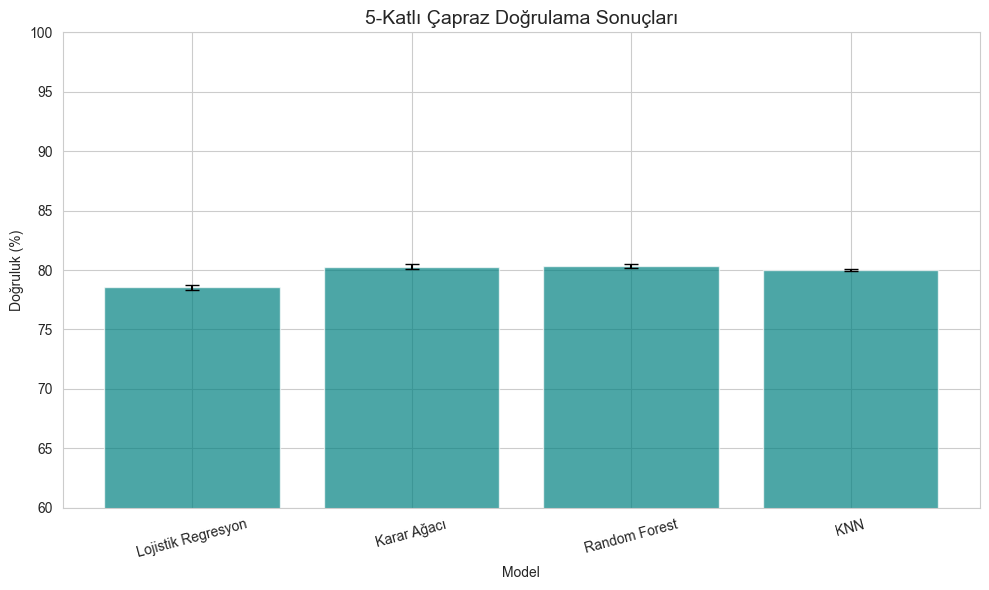

In [69]:
# Çapraz doğrulama sonuçları grafiği
# cv_sonuclari sözlüğünü DataFrame'e dönüştürelim
cv_df = (
	pd.DataFrame(cv_sonuclari).T.reset_index().rename(columns={'index': 'Model'})
)

plt.figure(figsize=(10, 6))
plt.bar(cv_df['Model'], cv_df['Ortalama'], yerr=cv_df['Std'], capsize=5, color='teal', alpha=0.7)
plt.xlabel('Model')
plt.ylabel('Doğruluk (%)')
plt.title('5-Katlı Çapraz Doğrulama Sonuçları', fontsize=14)
plt.ylim(0, 100)
plt.xticks(rotation=15)
plt.ylim(60, None)  # Y ekseni 50'den başlar

plt.tight_layout()
plt.show()

# 8. Sonuç ve Değerlendirme

## Model Performans Karşılaştırması

Bu projede teslimat başarısını tahmin etmek için dört farklı makine öğrenmesi modeli kullanılmıştır:

1. **Lojistik Regresyon**: Basit ve yorumlanabilir bir model olarak temel performans sağlamıştır.

2. **Karar Ağacı**: Kategorik değişkenlerle iyi çalışır ve özellik önem derecelerini gösterir.

3. **Random Forest**: En iyi performansı gösteren modeldir. Bunun nedenleri:
   - Birden fazla karar ağacının birleştirilmesi ile daha güçlü tahminler yapar
   - Verideki karmaşık ilişkileri ve kategorik değişkenleri daha iyi yönetir
   - Overfitting'e karşı daha dayanıklıdır

4. **KNN (K-En Yakın Komşu)**: Yüksek boyutlu veride iyi performans göstermiştir.

## Önemli Bulgular

- **Dengesiz Veri Problemi**: Veri setinde başarısız teslimatlar (%68.75) başarılı teslimatlardan (%31.25) çok daha fazladır. Bu sorunu çözmek için tüm modellerde `class_weight='balanced'` parametresi kullanılmıştır.

- **En Önemli Özellikler**: Karar Ağacı ve Random Forest modellerinin özellik önem dereceleri incelendiğinde, kargo maliyeti (ShipCost$), hizmet seviyesi (ServiceLevel) ve depo işleme süresi (Warehouse_Process_Days) en etkili değişkenler olarak öne çıkmaktadır.

- **F1-Score**: Dengesiz veri setlerinde accuracy yanıltıcı olabileceğinden, F1-Score metriği de değerlendirilmiştir.

## Sonuç

Random Forest modeli, test setinde en yüksek doğruluk oranını elde etmiştir. Bu model, e-ticaret şirketleri için teslimat süreçlerini optimize etmede kullanılabilir. Özellikle gecikme riski yüksek olan siparişler önceden tespit edilerek müşteri memnuniyeti artırılabilir.